In [4]:
import requests

In [5]:
URL = "https://www.bikewale.com/"
response = requests.get(URL)
response

<Response [200]>

In [7]:
page_content = response.text

In [8]:
print(len(page_content))

571318


In [9]:
import requests

url = "https://www.bikewale.com/new-bike-search/?pageNumber=1"

response = requests.get(
    url,
    headers={
        "User-Agent": "Mozilla/5.0"
    },
    timeout=20
)

print("Status Code:", response.status_code)
print("Content Length:", len(response.text))

Status Code: 200
Content Length: 467790


In [10]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

bike_links = [
    a for a in soup.select('a[href*="-bikes/"]')
    if (
        a.get("href")
        and len([x for x in a.get("href").split("/") if x]) == 2
        and not a.get("href").startswith("/new-bike-search/")
    )
]

print("Bike links found:", len(bike_links))

Bike links found: 30


In [12]:
bike = bike_links[0]

print("Name:", bike.get("title"))
print("URL:", bike.get("href"))

card = bike.find_parent("li")

print("\nCARD FOUND:", card is not None)

if card:
    print("\nCARD TEXT:")
    print(card.get_text(" ", strip=True))

Name: Honda SP 125
URL: /honda-bikes/sp-125/

CARD FOUND: True

CARD TEXT:
Honda SP 125 4.6 /5 4548 Ratings 123.94 cc | 63 kmpl | 10.72 bhp | 117 kg ₹ 90,636 Avg. Ex-Showroom price Check On-Road Price


In [13]:
print(card.prettify()[:5000])

<li class="o-em o-hk">
 <div>
  <div class="o-lT o-mO o-mf o-n9 o-iD o-eD o-C" data-skin="bg">
   <div class="o-an o-C" style="top:8px;left:8px">
   </div>
   <div class="o-bQ o-cm o-cA o-c4 o-kY o-f o-aw">
    <div class="o-f o-hl o-aE">
     <div class="o-f o-f3">
      <div style="width:136px" title="Honda SP 125">
       <div class="o-C o-dqdsFD o-aS">
        <div class="o-hl o-C o-o KW2bzQ">
         <img alt="Honda SP 125" class="o-D o-hP o-iB o-iT o-G o-Q o-a0 o-aa o-hl o-ed" src="https://imgd.aeplcdn.com/272x153/n/cw/ec/43482/sp-125-right-side-view-8.jpeg?isig=0&amp;q=80" title="Honda SP 125"/>
        </div>
       </div>
      </div>
     </div>
     <div class="o-f7 o-o">
      <a class="" href="/honda-bikes/sp-125/" title="Honda SP 125">
       <h3 class="o-c6">
        <span class="o-jJ o-j3 o-js o-ez">
         Honda SP 125
        </span>
        <svg aria-hidden="true" class="o-aQ o-aS o-aV o-ov o-gS o-ib o-jJ" fill="currentcolor" focusable="false" role="img" tabindex=

In [14]:
import re

# First bike card
bike = bike_links[0]
card = bike.find_parent("li")

# Bike name and URL
bike_name = bike.get("title")
bike_url = bike.get("href")

# Rating
rating_text = card.find("p").get_text(" ", strip=True)
rating = float(re.search(r"\d+(\.\d+)?", rating_text).group())

# Rating count
rating_count_text = card.find(
    string=re.compile(r"Ratings")
).strip()
rating_count = int(re.search(r"[\d,]+", rating_count_text).group().replace(",", ""))

# Specifications
specs = [
    span.get_text(" ", strip=True)
    for span in card.select("div.FTJfQA span.o-jK")
]

print("Bike Name:", bike_name)
print("Bike URL:", bike_url)
print("Rating:", rating)
print("Rating Count:", rating_count)
print("Specifications:", specs)

Bike Name: Honda SP 125
Bike URL: /honda-bikes/sp-125/
Rating: 4.6
Rating Count: 4548
Specifications: ['123.94 cc', '63 kmpl', '10.72 bhp', '117 kg']


In [15]:
price_text = card.find(
    string=re.compile(r"₹")
).strip()

print("Price Text:", price_text)

Price Text: ₹ 90,636


In [16]:
# Convert specifications to numeric values
engine_cc = float(re.search(r"[\d.]+", specs[0]).group())
mileage_kmpl = float(re.search(r"[\d.]+", specs[1]).group())
power_bhp = float(re.search(r"[\d.]+", specs[2]).group())
weight_kg = float(re.search(r"[\d.]+", specs[3]).group())

# Convert price to numeric
price = int(
    re.sub(r"[^\d]", "", price_text)
)

print("Engine CC:", engine_cc)
print("Mileage KMPL:", mileage_kmpl)
print("Power BHP:", power_bhp)
print("Weight KG:", weight_kg)
print("Price:", price)

Engine CC: 123.94
Mileage KMPL: 63.0
Power BHP: 10.72
Weight KG: 117.0
Price: 90636


In [17]:
bike_data = {
    "bike_name": bike_name,
    "bike_url": bike_url,
    "rating": rating,
    "rating_count": rating_count,
    "engine_cc": engine_cc,
    "mileage_kmpl": mileage_kmpl,
    "power_bhp": power_bhp,
    "weight_kg": weight_kg,
    "ex_showroom_price": price
}

bike_data

{'bike_name': 'Honda SP 125',
 'bike_url': '/honda-bikes/sp-125/',
 'rating': 4.6,
 'rating_count': 4548,
 'engine_cc': 123.94,
 'mileage_kmpl': 63.0,
 'power_bhp': 10.72,
 'weight_kg': 117.0,
 'ex_showroom_price': 90636}

In [18]:
all_bikes = []

for bike in bike_links:
    card = bike.find_parent("li")

    try:
        # Basic information
        bike_name = bike.get("title")
        bike_url = bike.get("href")

        # Rating
        rating_text = card.find("p").get_text(" ", strip=True)
        rating_match = re.search(r"\d+(\.\d+)?", rating_text)
        rating = float(rating_match.group()) if rating_match else None

        # Rating count
        rating_match = re.search(
            r"[\d,]+(?=\s*Ratings)",
            card.get_text(" ", strip=True)
        )
        rating_count = (
            int(rating_match.group().replace(",", ""))
            if rating_match else None
        )

        # Specifications
        specs = [
            span.get_text(" ", strip=True)
            for span in card.select("div.FTJfQA span.o-jK")
        ]

        # Extract numeric values from first four specifications
        engine_cc = (
            float(re.search(r"[\d.]+", specs[0]).group())
            if len(specs) > 0 and re.search(r"[\d.]+", specs[0])
            else None
        )

        mileage_kmpl = (
            float(re.search(r"[\d.]+", specs[1]).group())
            if len(specs) > 1 and re.search(r"[\d.]+", specs[1])
            else None
        )

        power_bhp = (
            float(re.search(r"[\d.]+", specs[2]).group())
            if len(specs) > 2 and re.search(r"[\d.]+", specs[2])
            else None
        )

        weight_kg = (
            float(re.search(r"[\d.]+", specs[3]).group())
            if len(specs) > 3 and re.search(r"[\d.]+", specs[3])
            else None
        )

        # Price
        price_match = re.search(
            r"₹\s*([\d,]+)",
            card.get_text(" ", strip=True)
        )
        price = (
            int(price_match.group(1).replace(",", ""))
            if price_match else None
        )

        all_bikes.append({
            "bike_name": bike_name,
            "bike_url": bike_url,
            "rating": rating,
            "rating_count": rating_count,
            "engine_cc": engine_cc,
            "mileage_kmpl": mileage_kmpl,
            "power_bhp": power_bhp,
            "weight_kg": weight_kg,
            "ex_showroom_price": price
        })

    except Exception as e:
        print(f"Error extracting {bike.get('title')}: {e}")

print("Records extracted:", len(all_bikes))

Records extracted: 30


In [19]:
import pandas as pd

df = pd.DataFrame(all_bikes)

print("Shape:", df.shape)

df.head()

Shape: (30, 9)


,bike_name,bike_url,rating,rating_count,engine_cc,mileage_kmpl,power_bhp,weight_kg,ex_showroom_price
0,Honda SP 125,/honda-bikes/sp-125/,4.6,4548,123.94,63.0,10.72,117.0,90636
1,Yamaha MT 15 V2,/yamaha-bikes/mt-15/,4.7,1866,155.00,47.0,18.10,141.0,166582
2,Royal Enfield Hunter 350,/royalenfield-bikes/hunter-350/,4.7,1792,349.34,36.2,20.20,181.0,137640
3,Royal Enfield Classic 350,/royalenfield-bikes/classic-350/,4.6,47,349.00,34.0,20.20,195.0,187434
4,Bajaj Pulsar N160 2V,/bajaj-bikes/pulsar-n160/,4.6,1278,164.82,51.6,15.68,152.0,122990


In [20]:
df.dtypes

bike_name                str
bike_url                 str
rating               float64
rating_count           int64
engine_cc            float64
mileage_kmpl         float64
power_bhp            float64
weight_kg            float64
ex_showroom_price      int64
dtype: object

In [21]:
df.isnull().sum()

bike_name            0
bike_url             0
rating               0
rating_count         0
engine_cc            0
mileage_kmpl         0
power_bhp            0
weight_kg            0
ex_showroom_price    0
dtype: int64

In [22]:
url_page2 = "https://www.bikewale.com/new-bike-search/?pageNumber=2"

response_page2 = requests.get(
    url_page2,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=20
)

print("Status Code:", response_page2.status_code)
print("Content Length:", len(response_page2.text))

Status Code: 200
Content Length: 465524


In [23]:
soup_page2 = BeautifulSoup(response_page2.text, "html.parser")

bike_links_page2 = [
    a for a in soup_page2.select('a[href*="-bikes/"]')
    if (
        a.get("href")
        and len([x for x in a.get("href").split("/") if x]) == 2
        and not a.get("href").startswith("/new-bike-search/")
    )
]

print("Bike links found:", len(bike_links_page2))
print("First 5 bikes:")

for bike in bike_links_page2[:5]:
    print(bike.get("title"))

Bike links found: 30
First 5 bikes:
Bajaj Pulsar NS200
Yamaha Ray ZR 125
Honda CB350RS
Suzuki Access 125
Bajaj Pulsar N160 4V


In [24]:
def extract_bike_data(bike):

    card = bike.find_parent("li")

    # Bike name and URL
    bike_name = bike.get("title")
    bike_url = bike.get("href")

    # Rating
    rating_text = card.find("p").get_text(" ", strip=True)
    rating_match = re.search(r"\d+(\.\d+)?", rating_text)
    rating = float(rating_match.group()) if rating_match else None

    # Rating count
    rating_match = re.search(
        r"[\d,]+(?=\s*Ratings)",
        card.get_text(" ", strip=True)
    )
    rating_count = (
        int(rating_match.group().replace(",", ""))
        if rating_match else None
    )

    # Specifications
    specs = [
        span.get_text(" ", strip=True)
        for span in card.select("div.FTJfQA span.o-jK")
    ]

    # Convert specifications to numeric values
    values = []

    for spec in specs[:4]:
        match = re.search(r"[\d.]+", spec)
        values.append(float(match.group()) if match else None)

    while len(values) < 4:
        values.append(None)

    engine_cc, mileage_kmpl, power_bhp, weight_kg = values

    # Price
    price_match = re.search(
        r"₹\s*([\d,]+)",
        card.get_text(" ", strip=True)
    )
    price = (
        int(price_match.group(1).replace(",", ""))
        if price_match else None
    )

    return {
        "bike_name": bike_name,
        "bike_url": bike_url,
        "rating": rating,
        "rating_count": rating_count,
        "engine_cc": engine_cc,
        "mileage_kmpl": mileage_kmpl,
        "power_bhp": power_bhp,
        "weight_kg": weight_kg,
        "ex_showroom_price": price
    }

In [25]:
test_bike = extract_bike_data(bike_links[0])

test_bike

{'bike_name': 'Honda SP 125',
 'bike_url': '/honda-bikes/sp-125/',
 'rating': 4.6,
 'rating_count': 4548,
 'engine_cc': 123.94,
 'mileage_kmpl': 63.0,
 'power_bhp': 10.72,
 'weight_kg': 117.0,
 'ex_showroom_price': 90636}

In [27]:
for page in range(1, 4):

    url = f"https://www.bikewale.com/new-bike-search/?pageNumber={page}"

    response = requests.get(
        url,
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=20
    )

    soup = BeautifulSoup(response.text, "html.parser")

    bike_links = [
        a for a in soup.select('a[href*="-bikes/"]')
        if (
            a.get("href")
            and len([x for x in a.get("href").split("/") if x]) == 2
            and not a.get("href").startswith("/new-bike-search/")
        )
    ]

    for bike in bike_links:

        card = bike.find_parent("li")

        if card is None or card.find("p") is None:
            print(
                "Problem found:",
                bike.get("title"),
                "|",
                bike.get("href")
            )

Problem found: Honda ADV 160 | /honda-bikes/adv-160/


In [29]:
url = "https://www.bikewale.com/new-bike-search/?pageNumber=3"

response = requests.get(
    url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=20
)

soup = BeautifulSoup(response.text, "html.parser")

adv_bike = soup.find(
    "a",
    attrs={"title": "Honda ADV 160"}
)

print("Found:", adv_bike is not None)

if adv_bike:
    print("Name:", adv_bike.get("title"))
    print("URL:", adv_bike.get("href"))

Found: True
Name: Honda ADV 160
URL: /honda-bikes/adv-160/


In [30]:
adv_card = adv_bike.find_parent("li")

print(adv_card.prettify()[:5000])

<li class="o-em o-hk">
 <div>
  <div class="o-lT o-mO o-mf o-n9 o-iD o-C" data-skin="bg">
   <div class="o-an o-C" style="top:8px;left:8px">
   </div>
   <div class="o-bQ o-cm o-cA o-c4 o-kY o-f o-aw">
    <div class="o-f o-hl o-aE">
     <div class="o-f o-f3">
      <div style="width:136px" title="Honda ADV 160">
       <div class="o-C o-dqdsFD o-aS">
        <div class="o-hl o-C o-o KW2bzQ">
         <img alt="Honda ADV 160" class="o-D o-hP o-iB o-iT o-G o-Q o-a0 o-aa o-hl o-ed" data-src="https://imgd.aeplcdn.com/272x153/n/cw/ec/224854/adv-160-right-front-three-quarter-2.png?isig=0&amp;q=80" src="https://imgd.aeplcdn.com/0x0/statics/grey-16x9.svg" title="Honda ADV 160"/>
        </div>
       </div>
      </div>
     </div>
     <div class="o-f7 o-o">
      <a class="" href="/honda-bikes/adv-160/" title="Honda ADV 160">
       <h3 class="o-c6">
        <span class="o-jJ o-j3 o-js o-ez">
         Honda ADV 160
        </span>
        <!--$-->
        <svg aria-hidden="true" class="o-a

In [31]:
print("Specifications:", [
    span.get_text(" ", strip=True)
    for span in adv_card.select("div.FTJfQA span.o-jK")
])

print("Rating elements:", len(adv_card.find_all("p")))

print("Rating text:",
      adv_card.find(string=re.compile(r"Ratings")))

Specifications: ['156.9 cc', '16.9 bhp']
Rating elements: 0
Rating text: None


In [32]:
def extract_bike_data(bike):

    card = bike.find_parent("li")

    # -------------------------
    # Bike name and URL
    # -------------------------
    bike_name = bike.get("title")
    bike_url = bike.get("href")

    # -------------------------
    # Rating
    # -------------------------
    rating = None
    rating_count = None

    rating_element = card.find("p")

    if rating_element:
        rating_text = rating_element.get_text(" ", strip=True)

        rating_match = re.search(r"\d+(\.\d+)?", rating_text)

        if rating_match:
            rating = float(rating_match.group())

        rating_count_match = re.search(
            r"[\d,]+(?=\s*Ratings)",
            card.get_text(" ", strip=True)
        )

        if rating_count_match:
            rating_count = int(
                rating_count_match.group().replace(",", "")
            )

    # -------------------------
    # Specifications
    # -------------------------
    specs = [
        span.get_text(" ", strip=True)
        for span in card.select("div.FTJfQA span.o-jK")
    ]

    engine_cc = None
    mileage_kmpl = None
    power_bhp = None
    weight_kg = None

    for spec in specs:

        value_match = re.search(r"[\d.]+", spec)

        if not value_match:
            continue

        value = float(value_match.group())

        if "cc" in spec.lower():
            engine_cc = value

        elif "kmpl" in spec.lower():
            mileage_kmpl = value

        elif "bhp" in spec.lower():
            power_bhp = value

        elif "kg" in spec.lower():
            weight_kg = value

    # -------------------------
    # Price
    # -------------------------
    price = None

    price_match = re.search(
        r"₹\s*([\d,]+)",
        card.get_text(" ", strip=True)
    )

    if price_match:
        price = int(
            price_match.group(1).replace(",", "")
        )

    # -------------------------
    # Return clean record
    # -------------------------
    return {
        "bike_name": bike_name,
        "bike_url": bike_url,
        "rating": rating,
        "rating_count": rating_count,
        "engine_cc": engine_cc,
        "mileage_kmpl": mileage_kmpl,
        "power_bhp": power_bhp,
        "weight_kg": weight_kg,
        "ex_showroom_price": price
    }

In [33]:
adv_data = extract_bike_data(adv_bike)

adv_data

{'bike_name': 'Honda ADV 160',
 'bike_url': '/honda-bikes/adv-160/',
 'rating': None,
 'rating_count': None,
 'engine_cc': 156.9,
 'mileage_kmpl': None,
 'power_bhp': 16.9,
 'weight_kg': None,
 'ex_showroom_price': 170000}

In [34]:
all_bikes_test = []

for page in range(1, 4):

    url = f"https://www.bikewale.com/new-bike-search/?pageNumber={page}"

    response = requests.get(
        url,
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=20
    )

    soup = BeautifulSoup(response.text, "html.parser")

    bike_links = [
        a for a in soup.select('a[href*="-bikes/"]')
        if (
            a.get("href")
            and len([x for x in a.get("href").split("/") if x]) == 2
            and not a.get("href").startswith("/new-bike-search/")
        )
    ]

    for bike in bike_links:
        data = extract_bike_data(bike)
        all_bikes_test.append(data)

print("Total records:", len(all_bikes_test))

Total records: 90


In [35]:
df_test = pd.DataFrame(all_bikes_test)

print("\nShape:", df_test.shape)

print("\nMissing values:")
print(df_test.isnull().sum())


Shape: (90, 9)

Missing values:
bike_name            0
bike_url             0
rating               1
rating_count         1
engine_cc            5
mileage_kmpl         6
power_bhp            5
weight_kg            5
ex_showroom_price    0
dtype: int64


In [36]:
df_test[
    df_test.isnull().any(axis=1)
][[
    "bike_name",
    "rating",
    "rating_count",
    "engine_cc",
    "mileage_kmpl",
    "power_bhp",
    "weight_kg",
    "ex_showroom_price"
]]

,bike_name,rating,rating_count,engine_cc,mileage_kmpl,power_bhp,weight_kg,ex_showroom_price
10,TVS iQube,3.7,880.0,NaN,NaN,NaN,129.7,119251
16,Ather Konarc,4.8,37.0,NaN,NaN,NaN,129.0,100099
37,Bajaj Pulsar 125,3.4,17.0,124.4,50.0,11.8,NaN,93507
43,Bajaj Chetak,3.7,742.0,NaN,NaN,NaN,NaN,119056
63,Bajaj Pulsar 150,3.8,9.0,149.5,47.0,14.0,NaN,115300
70,VIDA VX2,4.3,287.0,NaN,NaN,NaN,NaN,109590
71,Ather Rizta,4.4,395.0,NaN,NaN,NaN,119.0,120705
89,Honda ADV 160,NaN,NaN,156.9,NaN,16.9,NaN,170000


In [37]:
for bike in bike_links_page2[:10]:
    print(bike.get("title"), "→", bike.get("href"))

Bajaj Pulsar NS200 → /bajaj-bikes/pulsar-ns/
Yamaha Ray ZR 125 → /yamaha-bikes/ray-zr-125/
Honda CB350RS → /honda-bikes/cb350rs/
Suzuki Access 125 → /suzuki-bikes/access-125/
Bajaj Pulsar N160 4V → /bajaj-bikes/pulsar-n160-4v/
KTM 250 Duke → /ktm-bikes/duke-250/
Yamaha R2 → /yamaha-bikes/r2/
Bajaj Pulsar 125 → /bajaj-bikes/pulsar-125/
TVS Apache RTR 160 4V → /tvs-bikes/apache-rtr-160-4v/
Yamaha FZ S Hybrid → /yamaha-bikes/fz-s-hybrid/


In [38]:
for bike in bike_links_page2[:10]:

    href = bike.get("href")

    parts = [x for x in href.split("/") if x]

    brand_slug = parts[0].replace("-bikes", "")

    brand = brand_slug.replace("-", " ").title()

    print(bike.get("title"), "→", brand)

Bajaj Pulsar NS200 → Bajaj
Yamaha Ray ZR 125 → Yamaha
Honda CB350RS → Honda
Suzuki Access 125 → Suzuki
Bajaj Pulsar N160 4V → Bajaj
KTM 250 Duke → Ktm
Yamaha R2 → Yamaha
Bajaj Pulsar 125 → Bajaj
TVS Apache RTR 160 4V → Tvs
Yamaha FZ S Hybrid → Yamaha


In [39]:
def clean_brand(brand_slug):

    brand = brand_slug.replace("-bikes", "")
    brand = brand.replace("-", " ").strip().title()

    brand_mapping = {
        "Ktm": "KTM",
        "Tvs": "TVS",
        "Bmw": "BMW",
        "Ev": "EV",
        "Ola": "Ola"
    }

    return brand_mapping.get(brand, brand)

In [40]:
for bike in bike_links_page2[:10]:

    href = bike.get("href")
    parts = [x for x in href.split("/") if x]

    brand = clean_brand(parts[0])

    print(bike.get("title"), "→", brand)

Bajaj Pulsar NS200 → Bajaj
Yamaha Ray ZR 125 → Yamaha
Honda CB350RS → Honda
Suzuki Access 125 → Suzuki
Bajaj Pulsar N160 4V → Bajaj
KTM 250 Duke → KTM
Yamaha R2 → Yamaha
Bajaj Pulsar 125 → Bajaj
TVS Apache RTR 160 4V → TVS
Yamaha FZ S Hybrid → Yamaha


In [41]:
def extract_bike_data(bike):

    card = bike.find_parent("li")

    # -------------------------
    # Bike name and URL
    # -------------------------
    bike_name = bike.get("title")
    bike_url = bike.get("href")

    # -------------------------
    # Brand
    # -------------------------
    parts = [x for x in bike_url.split("/") if x]

    brand_slug = parts[0] if parts else None

    brand = clean_brand(brand_slug) if brand_slug else None

    # -------------------------
    # Rating
    # -------------------------
    rating = None
    rating_count = None

    rating_element = card.find("p")

    if rating_element:
        rating_text = rating_element.get_text(" ", strip=True)

        rating_match = re.search(r"\d+(\.\d+)?", rating_text)

        if rating_match:
            rating = float(rating_match.group())

        rating_count_match = re.search(
            r"[\d,]+(?=\s*Ratings)",
            card.get_text(" ", strip=True)
        )

        if rating_count_match:
            rating_count = int(
                rating_count_match.group().replace(",", "")
            )

    # -------------------------
    # Specifications
    # -------------------------
    specs = [
        span.get_text(" ", strip=True)
        for span in card.select("div.FTJfQA span.o-jK")
    ]

    engine_cc = None
    mileage_kmpl = None
    power_bhp = None
    weight_kg = None

    for spec in specs:

        value_match = re.search(r"[\d.]+", spec)

        if not value_match:
            continue

        value = float(value_match.group())

        if "cc" in spec.lower():
            engine_cc = value

        elif "kmpl" in spec.lower():
            mileage_kmpl = value

        elif "bhp" in spec.lower():
            power_bhp = value

        elif "kg" in spec.lower():
            weight_kg = value

    # -------------------------
    # Price
    # -------------------------
    price = None

    price_match = re.search(
        r"₹\s*([\d,]+)",
        card.get_text(" ", strip=True)
    )

    if price_match:
        price = int(
            price_match.group(1).replace(",", "")
        )

    # -------------------------
    # Return clean record
    # -------------------------
    return {
        "bike_name": bike_name,
        "brand": brand,
        "bike_url": bike_url,
        "rating": rating,
        "rating_count": rating_count,
        "engine_cc": engine_cc,
        "mileage_kmpl": mileage_kmpl,
        "power_bhp": power_bhp,
        "weight_kg": weight_kg,
        "ex_showroom_price": price
    }

In [42]:
adv_data = extract_bike_data(adv_bike)

adv_data

{'bike_name': 'Honda ADV 160',
 'brand': 'Honda',
 'bike_url': '/honda-bikes/adv-160/',
 'rating': None,
 'rating_count': None,
 'engine_cc': 156.9,
 'mileage_kmpl': None,
 'power_bhp': 16.9,
 'weight_kg': None,
 'ex_showroom_price': 170000}

In [46]:
import time

all_bikes_15_pages = []

for page in range(1, 16):

    url = f"https://www.bikewale.com/new-bike-search/?pageNumber={page}"

    response = requests.get(
        url,
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=20
    )

    print(f"Page {page} | Status: {response.status_code}")

    soup = BeautifulSoup(response.text, "html.parser")

    bike_links = [
        a for a in soup.select('a[href*="-bikes/"]')
        if (
            a.get("href")
            and len([x for x in a.get("href").split("/") if x]) == 2
            and not a.get("href").startswith("/new-bike-search/")
        )
    ]

    print(f"         Bikes found: {len(bike_links)}")

    for bike in bike_links:
        data = extract_bike_data(bike)
        all_bikes_15_pages.append(data)

    time.sleep(2)

print("\nTotal records collected:", len(all_bikes_15_pages))

Page 1 | Status: 200
         Bikes found: 30
Page 2 | Status: 200
         Bikes found: 30
Page 3 | Status: 200
         Bikes found: 30
Page 4 | Status: 200
         Bikes found: 30
Page 5 | Status: 200
         Bikes found: 30
Page 6 | Status: 200
         Bikes found: 30
Page 7 | Status: 200
         Bikes found: 30
Page 8 | Status: 200
         Bikes found: 30
Page 9 | Status: 200
         Bikes found: 30
Page 10 | Status: 200
         Bikes found: 30
Page 11 | Status: 200
         Bikes found: 30
Page 12 | Status: 200
         Bikes found: 30
Page 13 | Status: 200
         Bikes found: 30
Page 14 | Status: 200
         Bikes found: 30
Page 15 | Status: 200
         Bikes found: 24

Total records collected: 444


In [47]:
df_300 = pd.DataFrame(all_bikes_15_pages)

print("Total rows:", len(df_300))
print("Unique bike URLs:", df_300["bike_url"].nunique())
print("Duplicate rows:", df_300.duplicated().sum())

Total rows: 444
Unique bike URLs: 444
Duplicate rows: 0


In [48]:
duplicate_urls = df_300[
    df_300["bike_url"].duplicated(keep=False)
].sort_values("bike_url")

duplicate_urls[["bike_name", "brand", "bike_url"]]

,bike_name,brand,bike_url


In [49]:
df = pd.DataFrame(all_bikes_15_pages)

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
display(df.head())

Dataset Shape: (444, 10)

Column Names:
['bike_name', 'brand', 'bike_url', 'rating', 'rating_count', 'engine_cc', 'mileage_kmpl', 'power_bhp', 'weight_kg', 'ex_showroom_price']

First 5 Records:


,bike_name,brand,bike_url,rating,rating_count,engine_cc,mileage_kmpl,power_bhp,weight_kg,ex_showroom_price
0,Honda SP 125,Honda,/honda-bikes/sp-125/,4.6,4548.0,123.94,63.0,10.72,117.0,90636
1,Yamaha MT 15 V2,Yamaha,/yamaha-bikes/mt-15/,4.7,1866.0,155.00,47.0,18.10,141.0,166582
2,Royal Enfield Hunter 350,Royalenfield,/royalenfield-bikes/hunter-350/,4.7,1792.0,349.34,36.2,20.20,181.0,137640
3,Royal Enfield Classic 350,Royalenfield,/royalenfield-bikes/classic-350/,4.6,47.0,349.00,34.0,20.20,195.0,187434
4,Bajaj Pulsar N160 2V,Bajaj,/bajaj-bikes/pulsar-n160/,4.6,1278.0,164.82,51.6,15.68,152.0,122990


In [50]:
print("Total rows:", len(df))
print("Unique bike URLs:", df["bike_url"].nunique())
print("Duplicate rows:", df.duplicated().sum())

Total rows: 444
Unique bike URLs: 444
Duplicate rows: 0


In [51]:
duplicate_urls = df[
    df["bike_url"].duplicated(keep=False)
].sort_values("bike_url")

display(duplicate_urls[["bike_name", "brand", "bike_url"]])

,bike_name,brand,bike_url


In [52]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nMissing Value Percentage:")
print((df.isnull().mean() * 100).round(2))

Data Types:
bike_name                str
brand                    str
bike_url                 str
rating               float64
rating_count         float64
engine_cc            float64
mileage_kmpl         float64
power_bhp            float64
weight_kg            float64
ex_showroom_price      int64
dtype: object

Missing Values:
bike_name              0
brand                  0
bike_url               0
rating                44
rating_count          44
engine_cc            109
mileage_kmpl         174
power_bhp            117
weight_kg             27
ex_showroom_price      0
dtype: int64

Missing Value Percentage:
bike_name             0.00
brand                 0.00
bike_url              0.00
rating                9.91
rating_count          9.91
engine_cc            24.55
mileage_kmpl         39.19
power_bhp            26.35
weight_kg             6.08
ex_showroom_price     0.00
dtype: float64


In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 444 entries, 0 to 443
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bike_name          444 non-null    str    
 1   brand              444 non-null    str    
 2   bike_url           444 non-null    str    
 3   rating             400 non-null    float64
 4   rating_count       400 non-null    float64
 5   engine_cc          335 non-null    float64
 6   mileage_kmpl       270 non-null    float64
 7   power_bhp          327 non-null    float64
 8   weight_kg          417 non-null    float64
 9   ex_showroom_price  444 non-null    int64  
dtypes: float64(6), int64(1), str(3)
memory usage: 34.8 KB


In [54]:
missing_summary = df[df.isnull().any(axis=1)].copy()

print("Rows with at least one missing value:", len(missing_summary))

display(
    missing_summary[
        [
            "bike_name",
            "brand",
            "rating",
            "rating_count",
            "engine_cc",
            "mileage_kmpl",
            "power_bhp",
            "weight_kg"
        ]
    ].head(30)
)

Rows with at least one missing value: 200


,bike_name,brand,rating,rating_count,engine_cc,mileage_kmpl,power_bhp,weight_kg
10,TVS iQube,TVS,3.7,880.0,NaN,NaN,NaN,129.7
16,Ather Konarc,Ather,4.8,37.0,NaN,NaN,NaN,129.0
37,Bajaj Pulsar 125,Bajaj,3.4,17.0,124.40,50.0,11.80,NaN
43,Bajaj Chetak,Bajaj,3.7,742.0,NaN,NaN,NaN,NaN
63,Bajaj Pulsar 150,Bajaj,3.8,9.0,149.50,47.0,14.00,NaN
70,VIDA VX2,Vida,4.3,287.0,NaN,NaN,NaN,NaN
71,Ather Rizta,Ather,4.4,395.0,NaN,NaN,NaN,119.0
89,Honda ADV 160,Honda,NaN,NaN,156.90,NaN,16.90,NaN
97,TVS Orbiter,TVS,4.4,189.0,NaN,NaN,NaN,112.0
98,OLA S1 Z,Ola,4.0,12.0,NaN,NaN,NaN,132.7


In [55]:
mileage_missing_by_brand = (
    df.assign(mileage_missing=df["mileage_kmpl"].isna())
      .groupby("brand")["mileage_missing"]
      .agg(["sum", "count"])
      .sort_values("sum", ascending=False)
)

mileage_missing_by_brand["missing_percentage"] = (
    mileage_missing_by_brand["sum"]
    / mileage_missing_by_brand["count"]
    * 100
).round(2)

display(mileage_missing_by_brand)

,sum,count,missing_percentage
brand,,,
Kawasaki,18,39,46.15
KTM,9,24,37.50
Okinawa,8,8,100.00
Indian,7,11,63.64
Ola,7,7,100.00
Honda,7,27,25.93
Odysse,6,6,100.00
Ultraviolette,5,5,100.00
Ather,5,5,100.00


In [56]:
ev_keywords = [
    "iq", "chetak", "ather", "vida", "ola",
    "tesseract", "x47", "rorr", "konarc",
    "orbiter", "rizta", "vx2", "s1"
]

ev_pattern = "|".join(ev_keywords)

df["possible_ev"] = (
    df["bike_name"]
    .str.lower()
    .str.contains(ev_pattern, regex=True, na=False)
)

print("Possible EV records:", df["possible_ev"].sum())

display(
    df[df["possible_ev"]][
        [
            "bike_name",
            "brand",
            "engine_cc",
            "mileage_kmpl",
            "power_bhp",
            "weight_kg",
            "ex_showroom_price"
        ]
    ]
)

Possible EV records: 26


,bike_name,brand,engine_cc,mileage_kmpl,power_bhp,weight_kg,ex_showroom_price
10,TVS iQube,TVS,NaN,NaN,NaN,129.7,119251
16,Ather Konarc,Ather,NaN,NaN,NaN,129.0,100099
43,Bajaj Chetak,Bajaj,NaN,NaN,NaN,NaN,119056
50,Bajaj Pulsar NS125,Bajaj,124.45,46.9,11.80,144.0,94043
69,Bajaj Pulsar NS160,Bajaj,160.30,52.2,17.03,152.0,126819
70,VIDA VX2,Vida,NaN,NaN,NaN,NaN,109590
71,Ather Rizta,Ather,NaN,NaN,NaN,119.0,120705
97,TVS Orbiter,TVS,NaN,NaN,NaN,112.0,102459
98,OLA S1 Z,Ola,NaN,NaN,NaN,132.7,79999
101,BMW S1000RR,BMW,999.00,16.0,206.51,197.0,2375000


In [57]:
df = df.drop(columns=["possible_ev"])

print(df.shape)

(444, 10)


In [58]:
missing_analysis = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().mean() * 100).round(2)
})

missing_analysis = missing_analysis[
    missing_analysis["missing_count"] > 0
].sort_values("missing_percentage", ascending=False)

display(missing_analysis)

,missing_count,missing_percentage
mileage_kmpl,174,39.19
power_bhp,117,26.35
engine_cc,109,24.55
rating,44,9.91
rating_count,44,9.91
weight_kg,27,6.08


In [59]:
missing_by_brand = (
    df.groupby("brand")
      .agg(
          total_bikes=("bike_name", "count"),
          missing_engine=("engine_cc", lambda x: x.isna().sum()),
          missing_mileage=("mileage_kmpl", lambda x: x.isna().sum()),
          missing_power=("power_bhp", lambda x: x.isna().sum()),
          missing_weight=("weight_kg", lambda x: x.isna().sum()),
          missing_rating=("rating", lambda x: x.isna().sum())
      )
      .sort_values("total_bikes", ascending=False)
)

display(missing_by_brand)

,total_bikes,missing_engine,missing_mileage,missing_power,missing_weight,missing_rating
brand,,,,,,
Kawasaki,39,0,18,5,2,5
Triumph,29,0,4,0,0,6
Honda,27,2,7,2,1,2
Hero,25,0,0,0,0,0
KTM,24,0,9,0,0,3
Bajaj,23,2,4,2,3,0
TVS,22,3,3,3,1,0
Ducati,21,0,3,0,2,6
Royalenfield,17,1,2,1,0,0


In [60]:
numeric_columns = [
    "rating",
    "rating_count",
    "engine_cc",
    "mileage_kmpl",
    "power_bhp",
    "weight_kg",
    "ex_showroom_price"
]

for col in numeric_columns:
    print(f"\n{'=' * 50}")
    print(f"{col}")
    print(f"{'=' * 50}")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print("Negative values:", (df[col] < 0).sum())


rating
Minimum: 1.0
Maximum: 5.0
Negative values: 0

rating_count
Minimum: 1.0
Maximum: 4855.0
Negative values: 0

engine_cc
Minimum: 49.9
Maximum: 2458.0
Negative values: 0

mileage_kmpl
Minimum: 12.0
Maximum: 80.0
Negative values: 0

power_bhp
Minimum: 4.29
Maximum: 221.0
Negative values: 0

weight_kg
Minimum: 45.0
Maximum: 390.0
Negative values: 0

ex_showroom_price
Minimum: 47918
Maximum: 10000000
Negative values: 0


In [61]:
numeric_columns = [
    "rating",
    "rating_count",
    "engine_cc",
    "mileage_kmpl",
    "power_bhp",
    "weight_kg",
    "ex_showroom_price"
]

outlier_summary = []

for col in numeric_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ][col].count()
    
    outlier_summary.append({
        "column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outliers
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,rating,4.100,4.70,0.600,3.200000e+00,5.600000e+00,25
1,rating_count,6.000,183.50,177.500,-2.602500e+02,4.497500e+02,56
2,engine_cc,156.450,870.50,714.050,-9.146250e+02,1.941575e+03,1
3,mileage_kmpl,21.200,45.75,24.550,-1.562500e+01,8.257500e+01,0
4,power_bhp,15.145,82.40,67.255,-8.573750e+01,1.832825e+02,12
5,weight_kg,118.000,199.00,81.000,-3.500000e+00,3.205000e+02,6
6,ex_showroom_price,115182.250,863000.00,747817.750,-1.006544e+06,1.984727e+06,39


In [62]:
price_Q1 = df["ex_showroom_price"].quantile(0.25)
price_Q3 = df["ex_showroom_price"].quantile(0.75)
price_IQR = price_Q3 - price_Q1

price_upper_bound = price_Q3 + 1.5 * price_IQR

price_outliers = df[
    df["ex_showroom_price"] > price_upper_bound
].sort_values(
    "ex_showroom_price",
    ascending=False
)

print("Price upper bound:", round(price_upper_bound))

print("Number of price outliers:", len(price_outliers))

display(
    price_outliers[
        [
            "bike_name",
            "brand",
            "engine_cc",
            "power_bhp",
            "weight_kg",
            "rating",
            "ex_showroom_price"
        ]
    ]
)

Price upper bound: 1984727
Number of price outliers: 39


,bike_name,brand,engine_cc,power_bhp,weight_kg,rating,ex_showroom_price
143,Ducati Panigale V4 Lamborghini,Ducati,1103.0,216.00,185.0,4.1,10000000
217,Ducati Panigale V4 R,Ducati,998.0,221.00,193.5,4.2,8499000
285,Harley-Davidson Road Glide,Harleydavidson,1923.0,107.20,380.0,3.3,4575000
204,Honda Goldwing,Honda,1833.0,124.70,390.0,3.3,4430000
371,Ducati Multistrada V4 RS,Ducati,1103.0,180.00,260.0,4.5,4346700
352,Harley-Davidson Street Glide,Harleydavidson,1923.0,107.20,368.0,5.0,4250000
304,BMW K 1600,BMW,1649.0,158.00,358.0,5.0,3800000
215,Kawasaki Ninja H2 SX SE,Kawasaki,998.0,197.20,268.0,4.9,3627783
286,Harley-Davidson Breakout,Harleydavidson,1923.0,101.90,310.0,2.0,3436000
214,BMW M 1000 R,BMW,999.0,206.50,210.0,1.7,3350000


In [63]:
print("Number of unique brands:", df["brand"].nunique())

print("\nUnique brands:")
print(sorted(df["brand"].unique()))

Number of unique brands: 58

Unique brands:
['Ampere', 'Aprilia', 'Ather', 'Avore', 'BMW', 'Bajaj', 'Benelli', 'Bgauss', 'Bounce', 'Brixton Motorcycles', 'Bsa', 'Ducati', 'Evolet', 'Ferrato', 'Gemopai', 'Harleydavidson', 'Hero', 'Honda', 'Hop Electric', 'Husqvarna', 'Indian', 'Ivoomi', 'Jawa', 'Joyebike', 'KTM', 'Kawasaki', 'Keeway', 'Kinetic', 'Kinetic Green', 'Lectrix', 'Matter', 'Motoguzzi', 'Motomorini', 'Numeros', 'Oben', 'Odysse', 'Okinawa', 'Ola', 'Opg Mobility', 'Pureev', 'Qjmotor', 'Quantum Energy', 'Raptee', 'Revolt', 'River', 'Royalenfield', 'Simple Energy', 'Suzuki', 'TVS', 'Triumph', 'Ultraviolette', 'Vespa', 'Vida', 'Vlf', 'Yamaha', 'Yezdi', 'Yo', 'Zontes']


In [64]:
print("Brands with leading/trailing spaces:")

brand_spaces = df[
    df["brand"].str.strip() != df["brand"]
]["brand"].unique()

print(brand_spaces)

Brands with leading/trailing spaces:
<StringArray>
[]
Length: 0, dtype: str


In [65]:
brand_mapping = {
    "Bsa": "BSA",
    "Harleydavidson": "Harley-Davidson",
    "Royalenfield": "Royal Enfield",
    "Motoguzzi": "Moto Guzzi",
    "Motomorini": "Moto Morini",
    "Qjmotor": "QJ Motor",
    "Opg Mobility": "OPG Mobility",
    "Ivoomi": "iVOOMi",
    "Vlf": "VLF",
    "Bgauss": "BGauss",
    "Ola": "Ola Electric",
    "Vida": "VIDA",
    "Pureev": "PURE EV",
    "Joyebike": "Joy e-bike",
    "Odysse": "Odysse Electric",
    "Kinetic": "Kinetic",
    "Kinetic Green": "Kinetic Green"
}

df["brand_clean"] = df["brand"].replace(brand_mapping)

print("Original unique brands:", df["brand"].nunique())
print("Cleaned unique brands:", df["brand_clean"].nunique())

display(
    df[["brand", "brand_clean"]]
    .drop_duplicates()
    .sort_values(["brand", "brand_clean"])
)

Original unique brands: 58
Cleaned unique brands: 58


,brand,brand_clean
191,Ampere,Ampere
53,Aprilia,Aprilia
16,Ather,Ather
249,Avore,Avore
55,BMW,BMW
4,Bajaj,Bajaj
223,Benelli,Benelli
206,Bgauss,BGauss
408,Bounce,Bounce
324,Brixton Motorcycles,Brixton Motorcycles


In [66]:
df["price_segment"] = pd.cut(
    df["ex_showroom_price"],
    bins=[
        0,
        100000,
        200000,
        500000,
        1000000,
        float("inf")
    ],
    labels=[
        "Under 1 Lakh",
        "1–2 Lakh",
        "2–5 Lakh",
        "5–10 Lakh",
        "Above 10 Lakh"
    ],
    include_lowest=True
)

print(df["price_segment"].value_counts().sort_index())

price_segment
Under 1 Lakh      86
1–2 Lakh         142
2–5 Lakh          83
5–10 Lakh         33
Above 10 Lakh    100
Name: count, dtype: int64


In [67]:
df["power_to_weight"] = (
    df["power_bhp"] / df["weight_kg"]
)

print("Power-to-weight values created:",
      df["power_to_weight"].notna().sum())

display(
    df[
        [
            "bike_name",
            "power_bhp",
            "weight_kg",
            "power_to_weight"
        ]
    ].head(10)
)

Power-to-weight values created: 319


,bike_name,power_bhp,weight_kg,power_to_weight
0,Honda SP 125,10.72,117.0,0.091624
1,Yamaha MT 15 V2,18.10,141.0,0.128369
2,Royal Enfield Hunter 350,20.20,181.0,0.111602
3,Royal Enfield Classic 350,20.20,195.0,0.103590
4,Bajaj Pulsar N160 2V,15.68,152.0,0.103158
5,Royal Enfield Bullet 350,20.20,195.0,0.103590
6,Royal Enfield Himalayan 440,25.40,199.0,0.127638
7,TVS Ronin,20.10,160.0,0.125625
8,Jawa All Stars 42 Bobber,29.51,185.0,0.159514
9,TVS Raider 125,11.20,123.0,0.091057


In [68]:
df["price_per_bhp"] = (
    df["ex_showroom_price"] / df["power_bhp"]
)

print(
    "Price-per-bhp values created:",
    df["price_per_bhp"].notna().sum()
)

display(
    df[
        [
            "bike_name",
            "ex_showroom_price",
            "power_bhp",
            "price_per_bhp"
        ]
    ].head(10)
)

Price-per-bhp values created: 327


,bike_name,ex_showroom_price,power_bhp,price_per_bhp
0,Honda SP 125,90636,10.72,8454.850746
1,Yamaha MT 15 V2,166582,18.10,9203.425414
2,Royal Enfield Hunter 350,137640,20.20,6813.861386
3,Royal Enfield Classic 350,187434,20.20,9278.910891
4,Bajaj Pulsar N160 2V,122990,15.68,7843.750000
5,Royal Enfield Bullet 350,165656,20.20,8200.792079
6,Royal Enfield Himalayan 440,229000,25.40,9015.748031
7,TVS Ronin,130314,20.10,6483.283582
8,Jawa All Stars 42 Bobber,210979,29.51,7149.406981
9,TVS Raider 125,86397,11.20,7714.017857


In [69]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (444, 14)

Columns:
['bike_name', 'brand', 'bike_url', 'rating', 'rating_count', 'engine_cc', 'mileage_kmpl', 'power_bhp', 'weight_kg', 'ex_showroom_price', 'brand_clean', 'price_segment', 'power_to_weight', 'price_per_bhp']

Missing values:
bike_name              0
brand                  0
bike_url               0
rating                44
rating_count          44
engine_cc            109
mileage_kmpl         174
power_bhp            117
weight_kg             27
ex_showroom_price      0
brand_clean            0
price_segment          0
power_to_weight      125
price_per_bhp        117
dtype: int64

Data types:
bike_name                 str
brand                     str
bike_url                  str
rating                float64
rating_count          float64
engine_cc             float64
mileage_kmpl          float64
power_bhp             float64
weight_kg             float64
ex_showroom_price       int64
brand_clean               str
price_segment        category
power_t

In [70]:
df_clean = df.copy()

# Replace original brand with standardized brand
df_clean["brand"] = df_clean["brand_clean"]

# Remove the temporary duplicate brand column
df_clean.drop(columns=["brand_clean"], inplace=True)

print("Final dataset shape:", df_clean.shape)

print("\nFinal columns:")
print(df_clean.columns.tolist())

Final dataset shape: (444, 13)

Final columns:
['bike_name', 'brand', 'bike_url', 'rating', 'rating_count', 'engine_cc', 'mileage_kmpl', 'power_bhp', 'weight_kg', 'ex_showroom_price', 'price_segment', 'power_to_weight', 'price_per_bhp']


In [71]:
df_clean.to_csv(
    "bikewale_cleaned_data.csv",
    index=False
)

print("CSV exported successfully.")

CSV exported successfully.


In [72]:
df_analysis = pd.read_csv("bikewale_cleaned_data.csv")

print("Reloaded dataset shape:", df_analysis.shape)

display(df_analysis.head())

Reloaded dataset shape: (444, 13)


,bike_name,brand,bike_url,rating,rating_count,engine_cc,mileage_kmpl,power_bhp,weight_kg,ex_showroom_price,price_segment,power_to_weight,price_per_bhp
0,Honda SP 125,Honda,/honda-bikes/sp-125/,4.6,4548.0,123.94,63.0,10.72,117.0,90636,Under 1 Lakh,0.091624,8454.850746
1,Yamaha MT 15 V2,Yamaha,/yamaha-bikes/mt-15/,4.7,1866.0,155.00,47.0,18.10,141.0,166582,1–2 Lakh,0.128369,9203.425414
2,Royal Enfield Hunter 350,Royal Enfield,/royalenfield-bikes/hunter-350/,4.7,1792.0,349.34,36.2,20.20,181.0,137640,1–2 Lakh,0.111602,6813.861386
3,Royal Enfield Classic 350,Royal Enfield,/royalenfield-bikes/classic-350/,4.6,47.0,349.00,34.0,20.20,195.0,187434,1–2 Lakh,0.103590,9278.910891
4,Bajaj Pulsar N160 2V,Bajaj,/bajaj-bikes/pulsar-n160/,4.6,1278.0,164.82,51.6,15.68,152.0,122990,1–2 Lakh,0.103158,7843.750000


In [73]:
print("Number of observations:", df_analysis.shape[0])
print("Number of features:", df_analysis.shape[1])

print("\nFeature Information:")
display(
    pd.DataFrame({
        "Feature": df_analysis.columns,
        "Data Type": df_analysis.dtypes.astype(str),
        "Non-Null Count": df_analysis.notna().sum().values,
        "Missing Count": df_analysis.isna().sum().values
    })
)

Number of observations: 444
Number of features: 13

Feature Information:


,Feature,Data Type,Non-Null Count,Missing Count
bike_name,bike_name,str,444,0
brand,brand,str,444,0
bike_url,bike_url,str,444,0
rating,rating,float64,400,44
rating_count,rating_count,float64,400,44
engine_cc,engine_cc,float64,335,109
mileage_kmpl,mileage_kmpl,float64,270,174
power_bhp,power_bhp,float64,327,117
weight_kg,weight_kg,float64,417,27
ex_showroom_price,ex_showroom_price,int64,444,0


In [80]:
print("\nStatistical Summary:")
display(df_analysis.describe().T)


Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
rating,400.0,4.304500,6.486382e-01,1.000000,4.100000,4.500000,4.700000,5.000000e+00
rating_count,400.0,267.002500,6.681821e+02,1.000000,6.000000,24.500000,183.500000,4.855000e+03
engine_cc,335.0,533.667254,4.608245e+02,49.900000,156.450000,349.000000,870.500000,2.458000e+03
mileage_kmpl,270.0,34.444963,1.527539e+01,12.000000,21.200000,31.000000,45.750000,8.000000e+01
power_bhp,327.0,54.658777,5.174279e+01,4.290000,15.145000,36.490000,82.400000,2.210000e+02
weight_kg,417.0,165.162830,5.707057e+01,45.000000,118.000000,163.000000,199.000000,3.900000e+02
ex_showroom_price,444.0,658275.202703,1.029885e+06,47918.000000,115182.250000,198444.500000,863000.000000,1.000000e+07
power_to_weight,319.0,0.272601,2.268713e-01,0.048202,0.106729,0.197222,0.367021,1.167568e+00
price_per_bhp,327.0,12475.917820,7.904783e+03,4649.100899,8167.262067,10107.462687,14234.911200,8.962264e+04


In [81]:
df_analysis.describe()

,rating,rating_count,engine_cc,mileage_kmpl,power_bhp,weight_kg,ex_showroom_price,power_to_weight,price_per_bhp
count,400.000000,400.000000,335.000000,270.000000,327.000000,417.000000,4.440000e+02,319.000000,327.000000
mean,4.304500,267.002500,533.667254,34.444963,54.658777,165.162830,6.582752e+05,0.272601,12475.917820
std,0.648638,668.182128,460.824549,15.275388,51.742786,57.070573,1.029885e+06,0.226871,7904.782975
min,1.000000,1.000000,49.900000,12.000000,4.290000,45.000000,4.791800e+04,0.048202,4649.100899
25%,4.100000,6.000000,156.450000,21.200000,15.145000,118.000000,1.151822e+05,0.106729,8167.262067
50%,4.500000,24.500000,349.000000,31.000000,36.490000,163.000000,1.984445e+05,0.197222,10107.462687
75%,4.700000,183.500000,870.500000,45.750000,82.400000,199.000000,8.630000e+05,0.367021,14234.911200
max,5.000000,4855.000000,2458.000000,80.000000,221.000000,390.000000,1.000000e+07,1.167568,89622.641509


In [82]:
brand_counts = (
    df_analysis["brand"]
    .value_counts()
    .sort_values(ascending=False)
)

print("Number of unique brands:", brand_counts.shape[0])

display(brand_counts.head(15))

Number of unique brands: 58


brand
Kawasaki           39
Triumph            29
Honda              27
Hero               25
KTM                24
Bajaj              23
TVS                22
Ducati             21
Yamaha             17
Royal Enfield      17
BMW                15
Suzuki             14
Harley-Davidson    13
Indian             11
Aprilia            10
Name: count, dtype: int64

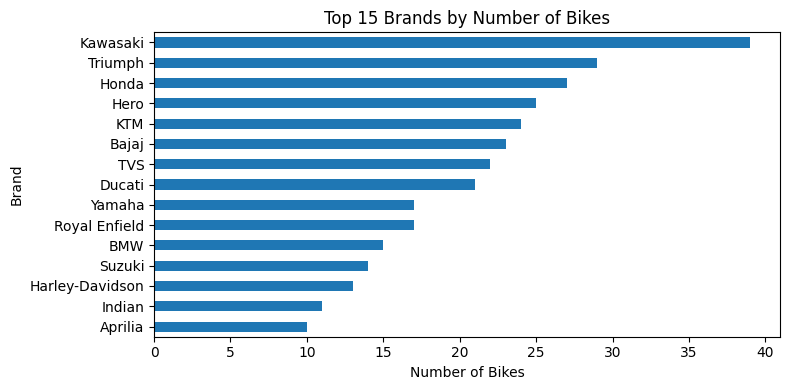

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

brand_counts.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Brands by Number of Bikes")
plt.xlabel("Number of Bikes")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

In [87]:
rating_distribution = (
    df_analysis["rating"]
    .value_counts()
    .sort_index()
)

print("Number of bikes with ratings:", df_analysis["rating"].notna().sum())

display(rating_distribution)

Number of bikes with ratings: 400


rating
1.0     1
1.7     1
2.0     3
2.3     1
2.4     1
2.5     8
2.6     2
2.8     1
2.9     1
3.0     4
3.1     2
3.2     4
3.3    11
3.4     7
3.5     7
3.6     4
3.7     7
3.8    12
3.9     4
4.0    14
4.1     7
4.2    15
4.3    27
4.4    34
4.5    47
4.6    46
4.7    43
4.8    34
4.9    14
5.0    38
Name: count, dtype: int64

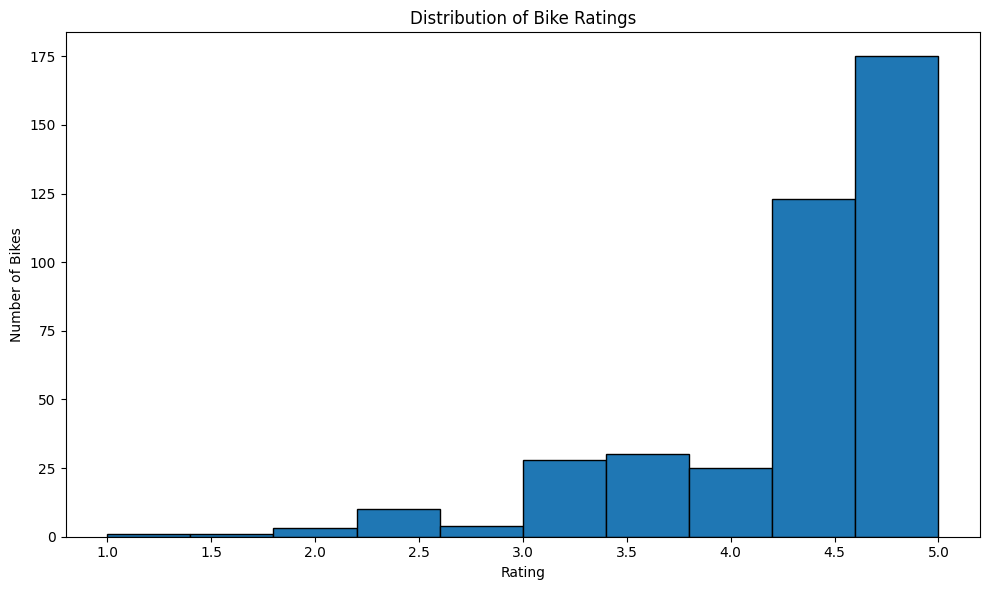

In [94]:
plt.figure(figsize=(10, 6))

df_analysis["rating"].dropna().plot(
    kind="hist",
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Bike Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Bikes")

plt.tight_layout()
plt.show()

In [95]:
price_stats = df_analysis["ex_showroom_price"].describe()

print("Price Statistics:")
display(price_stats)

Price Statistics:


count    4.440000e+02
mean     6.582752e+05
std      1.029885e+06
min      4.791800e+04
25%      1.151822e+05
50%      1.984445e+05
75%      8.630000e+05
max      1.000000e+07
Name: ex_showroom_price, dtype: float64

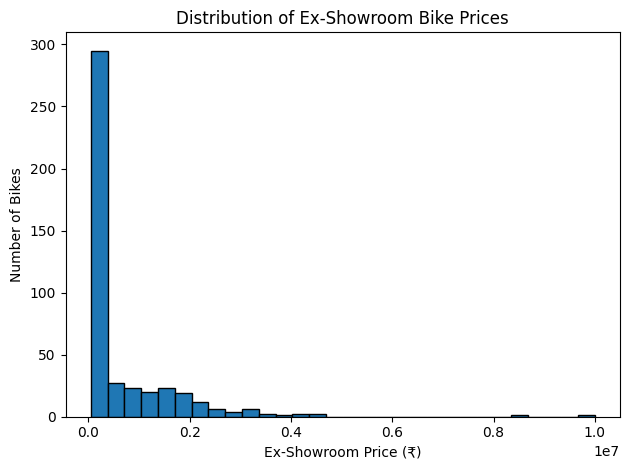

In [97]:
#plt.figure(figsize=(10, 6))

df_analysis["ex_showroom_price"].plot(
    kind="hist",
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Ex-Showroom Bike Prices")
plt.xlabel("Ex-Showroom Price (₹)")
plt.ylabel("Number of Bikes")

plt.tight_layout()
plt.show()

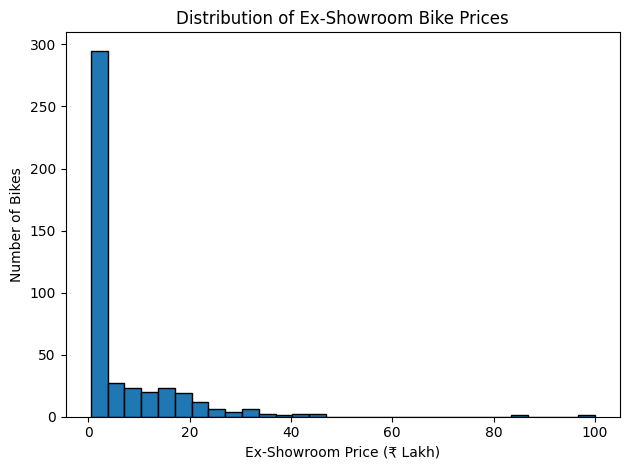

In [99]:
price_lakh = df_analysis["ex_showroom_price"] / 100000

#plt.figure(figsize=(10, 6))

price_lakh.plot(
    kind="hist",
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Ex-Showroom Bike Prices")
plt.xlabel("Ex-Showroom Price (₹ Lakh)")
plt.ylabel("Number of Bikes")

plt.tight_layout()
plt.show()

In [100]:
engine_stats = df_analysis["engine_cc"].describe()

print("Engine Capacity Statistics:")
display(engine_stats)

Engine Capacity Statistics:


count     335.000000
mean      533.667254
std       460.824549
min        49.900000
25%       156.450000
50%       349.000000
75%       870.500000
max      2458.000000
Name: engine_cc, dtype: float64

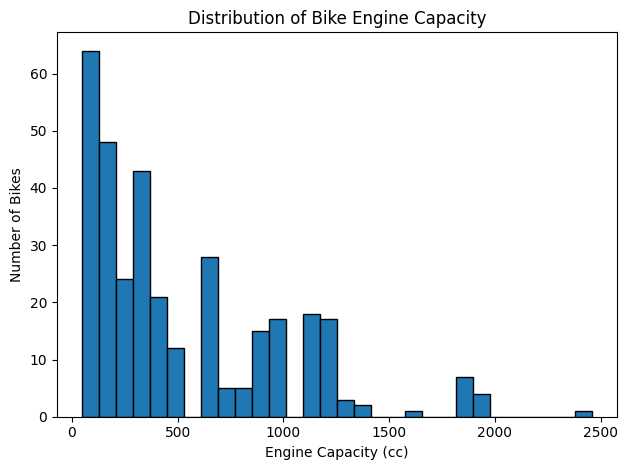

In [103]:
#plt.figure(figsize=(10, 6))

df_analysis["engine_cc"].dropna().plot(
    kind="hist",
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Bike Engine Capacity")
plt.xlabel("Engine Capacity (cc)")
plt.ylabel("Number of Bikes")

plt.tight_layout()
plt.show()

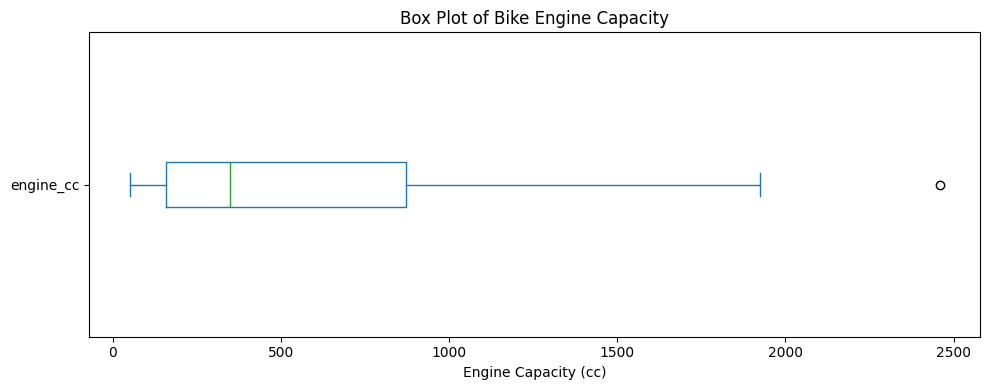

In [102]:
plt.figure(figsize=(10, 4))

df_analysis["engine_cc"].plot(
    kind="box",
    vert=False
)

plt.title("Box Plot of Bike Engine Capacity")
plt.xlabel("Engine Capacity (cc)")

plt.tight_layout()
plt.show()

In [104]:
mileage_stats = df_analysis["mileage_kmpl"].describe()

print("Mileage Statistics:")
display(mileage_stats)

Mileage Statistics:


count    270.000000
mean      34.444963
std       15.275388
min       12.000000
25%       21.200000
50%       31.000000
75%       45.750000
max       80.000000
Name: mileage_kmpl, dtype: float64

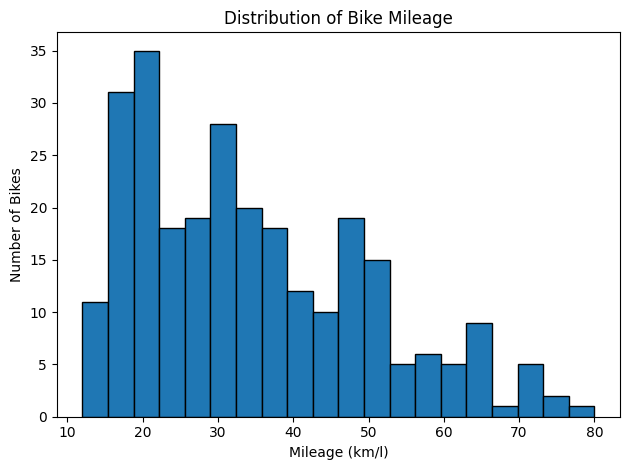

In [106]:
#plt.figure(figsize=(10, 6))

df_analysis["mileage_kmpl"].dropna().plot(
    kind="hist",
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Bike Mileage")
plt.xlabel("Mileage (km/l)")
plt.ylabel("Number of Bikes")

plt.tight_layout()
plt.show()

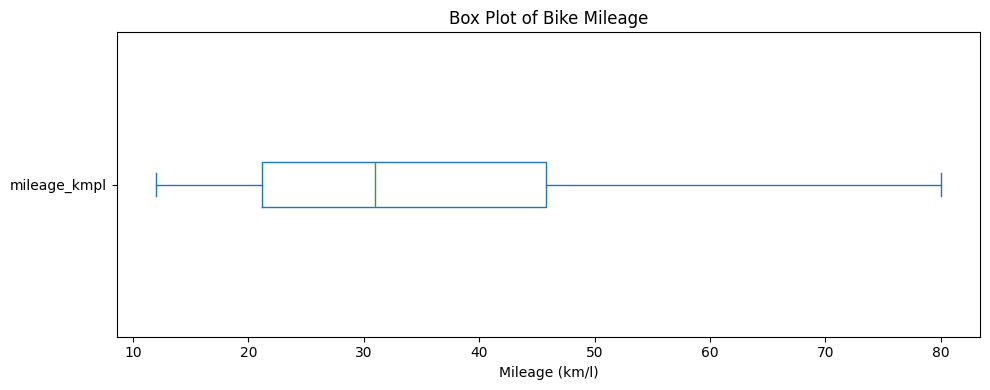

In [107]:
plt.figure(figsize=(10, 4))

df_analysis["mileage_kmpl"].plot(
    kind="box",
    vert=False
)

plt.title("Box Plot of Bike Mileage")
plt.xlabel("Mileage (km/l)")

plt.tight_layout()
plt.show()

In [108]:
power_stats = df_analysis["power_bhp"].describe()

print("Power Statistics:")
display(power_stats)

Power Statistics:


count    327.000000
mean      54.658777
std       51.742786
min        4.290000
25%       15.145000
50%       36.490000
75%       82.400000
max      221.000000
Name: power_bhp, dtype: float64

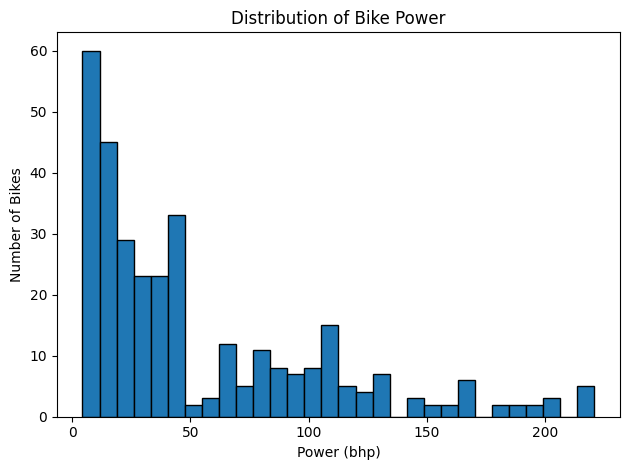

In [109]:
#plt.figure(figsize=(10, 6))

df_analysis["power_bhp"].dropna().plot(
    kind="hist",
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Bike Power")
plt.xlabel("Power (bhp)")
plt.ylabel("Number of Bikes")

plt.tight_layout()
plt.show()

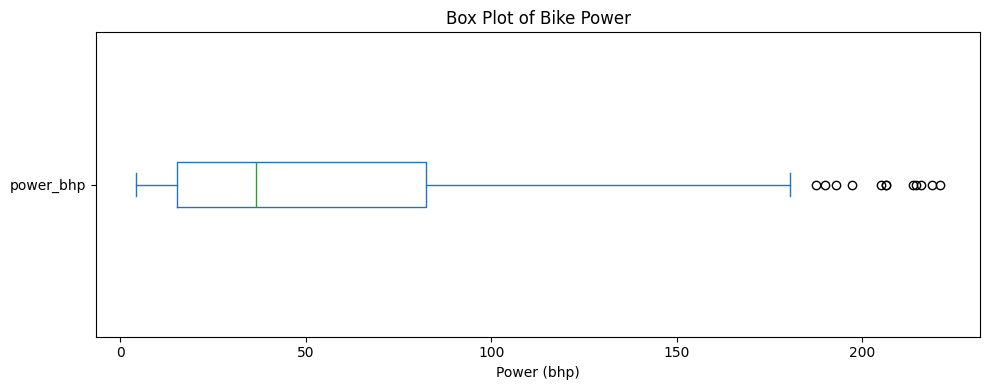

In [111]:
plt.figure(figsize=(10, 4))

df_analysis["power_bhp"].plot(
    kind="box",
    vert=False
)

plt.title("Box Plot of Bike Power")
plt.xlabel("Power (bhp)")

plt.tight_layout()
plt.show()

In [112]:
weight_stats = df_analysis["weight_kg"].describe()

print("Weight Statistics:")
display(weight_stats)

Weight Statistics:


count    417.000000
mean     165.162830
std       57.070573
min       45.000000
25%      118.000000
50%      163.000000
75%      199.000000
max      390.000000
Name: weight_kg, dtype: float64

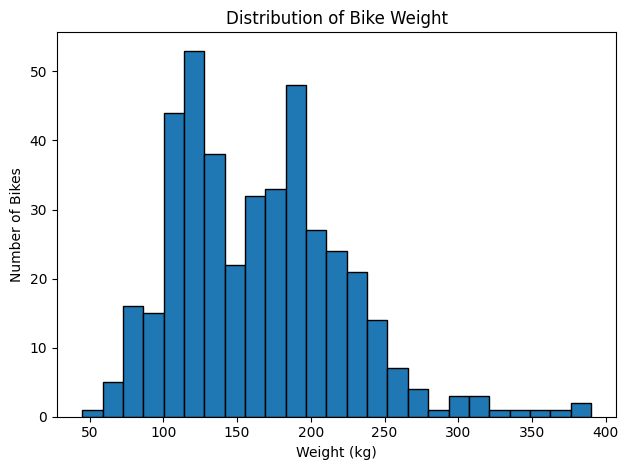

In [113]:
#plt.figure(figsize=(10, 6))

df_analysis["weight_kg"].dropna().plot(
    kind="hist",
    bins=25,
    edgecolor="black"
)

plt.title("Distribution of Bike Weight")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of Bikes")

plt.tight_layout()
plt.show()

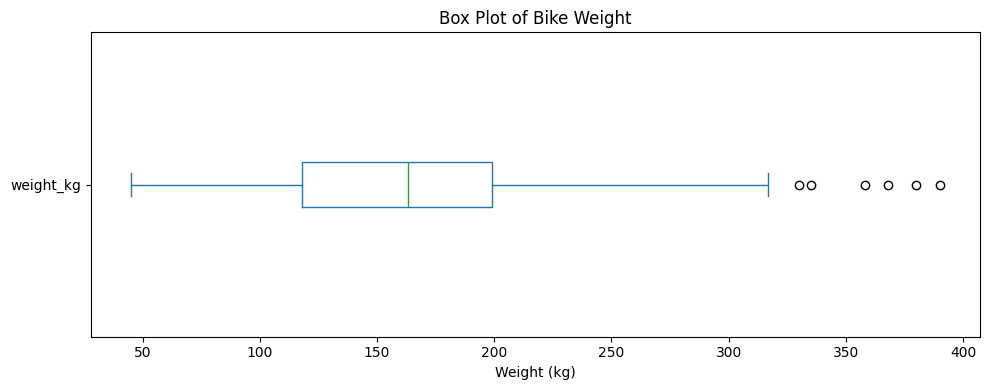

In [114]:
plt.figure(figsize=(10, 4))

df_analysis["weight_kg"].plot(
    kind="box",
    vert=False
)

plt.title("Box Plot of Bike Weight")
plt.xlabel("Weight (kg)")

plt.tight_layout()
plt.show()

In [115]:
rating_count_stats = df_analysis["rating_count"].describe()

print("Rating Count Statistics:")
display(rating_count_stats)

Rating Count Statistics:


count     400.000000
mean      267.002500
std       668.182128
min         1.000000
25%         6.000000
50%        24.500000
75%       183.500000
max      4855.000000
Name: rating_count, dtype: float64

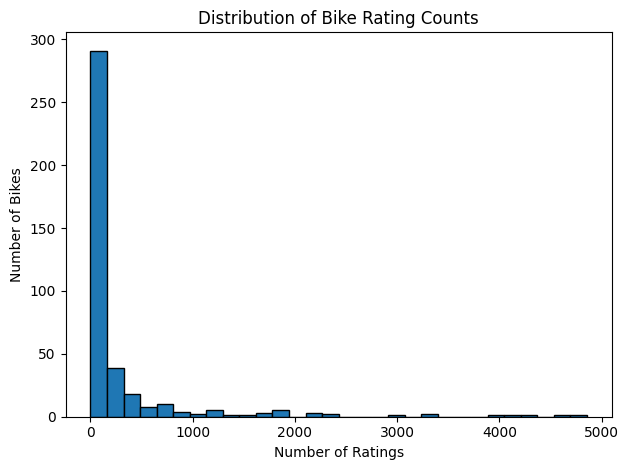

In [116]:
#plt.figure(figsize=(10, 6))

df_analysis["rating_count"].dropna().plot(
    kind="hist",
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Bike Rating Counts")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Bikes")

plt.tight_layout()
plt.show()

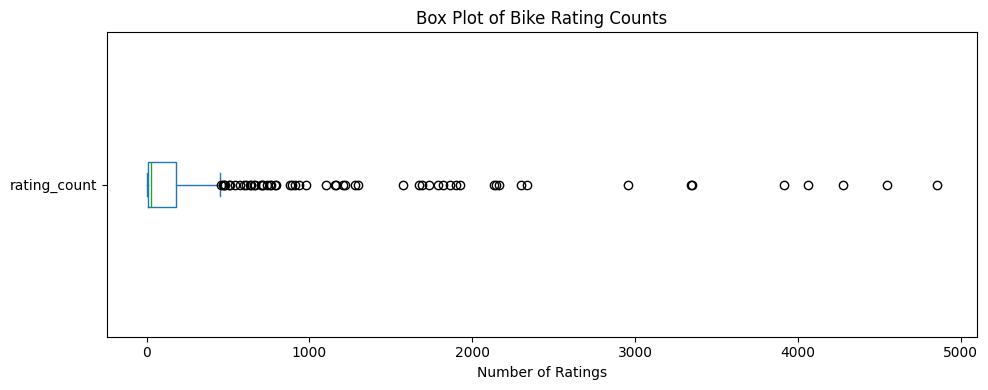

In [117]:
plt.figure(figsize=(10, 4))

df_analysis["rating_count"].plot(
    kind="box",
    vert=False
)

plt.title("Box Plot of Bike Rating Counts")
plt.xlabel("Number of Ratings")

plt.tight_layout()
plt.show()

In [118]:
engine_price_data = df_analysis[
    ["engine_cc", "ex_showroom_price"]
].dropna()

correlation = engine_price_data[
    "engine_cc"
].corr(
    engine_price_data["ex_showroom_price"]
)

print("Observations used:", len(engine_price_data))
print("Pearson correlation:", round(correlation, 3))

Observations used: 335
Pearson correlation: 0.756


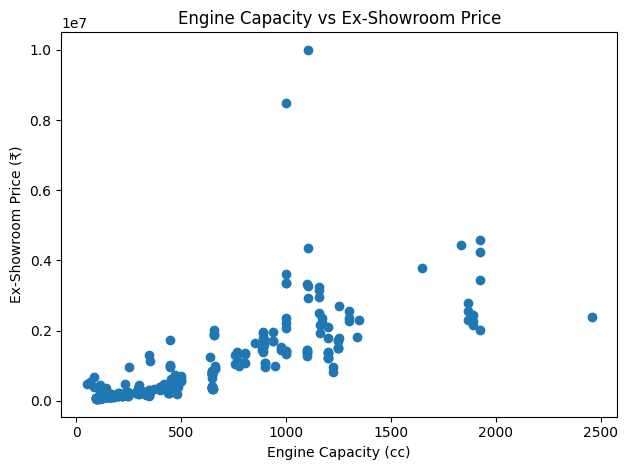

In [120]:
#plt.figure(figsize=(10, 6))

plt.scatter(
    engine_price_data["engine_cc"],
    engine_price_data["ex_showroom_price"]
)

plt.title("Engine Capacity vs Ex-Showroom Price")
plt.xlabel("Engine Capacity (cc)")
plt.ylabel("Ex-Showroom Price (₹)")

plt.tight_layout()
plt.show()

In [121]:
power_price_data = df_analysis[
    ["power_bhp", "ex_showroom_price"]
].dropna()

correlation = power_price_data[
    "power_bhp"
].corr(
    power_price_data["ex_showroom_price"]
)

print("Observations used:", len(power_price_data))
print("Pearson correlation:", round(correlation, 3))

Observations used: 327
Pearson correlation: 0.844


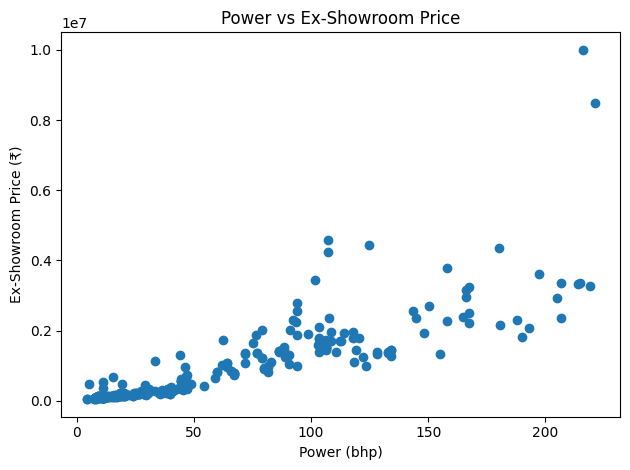

In [122]:
#plt.figure(figsize=(10, 6))

plt.scatter(
    power_price_data["power_bhp"],
    power_price_data["ex_showroom_price"]
)

plt.title("Power vs Ex-Showroom Price")
plt.xlabel("Power (bhp)")
plt.ylabel("Ex-Showroom Price (₹)")

plt.tight_layout()
plt.show()

In [123]:
price_segment_counts = (
    df_analysis["price_segment"]
    .value_counts()
    .reindex([
        "Under 1 Lakh",
        "1–2 Lakh",
        "2–5 Lakh",
        "5–10 Lakh",
        "Above 10 Lakh"
    ])
)

print("Bikes by Price Segment:")
display(price_segment_counts)

Bikes by Price Segment:


price_segment
Under 1 Lakh      86
1–2 Lakh         142
2–5 Lakh          83
5–10 Lakh         33
Above 10 Lakh    100
Name: count, dtype: int64

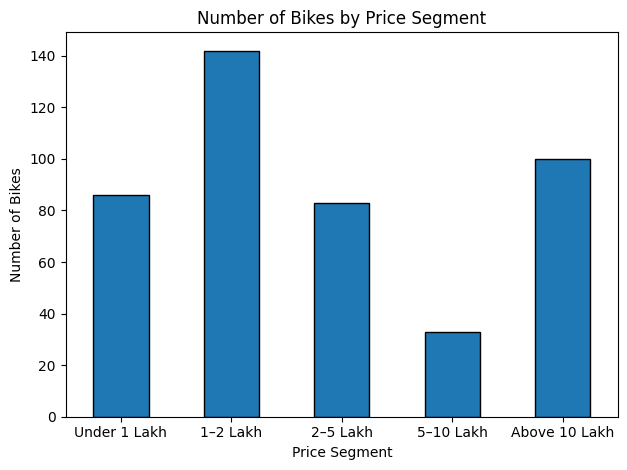

In [125]:
#plt.figure(figsize=(10, 6))

price_segment_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Number of Bikes by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Number of Bikes")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [126]:
price_segment_percentage = (
    price_segment_counts
    / price_segment_counts.sum()
    * 100
).round(2)

print("Percentage of Bikes by Price Segment:")
display(price_segment_percentage)

Percentage of Bikes by Price Segment:


price_segment
Under 1 Lakh     19.37
1–2 Lakh         31.98
2–5 Lakh         18.69
5–10 Lakh         7.43
Above 10 Lakh    22.52
Name: count, dtype: float64

In [127]:
top_15_brands = (
    df_analysis["brand"]
    .value_counts()
    .head(15)
    .index
    .tolist()
)

print("Top 15 brands:")
print(top_15_brands)

Top 15 brands:
['Kawasaki', 'Triumph', 'Honda', 'Hero', 'KTM', 'Bajaj', 'TVS', 'Ducati', 'Yamaha', 'Royal Enfield', 'BMW', 'Suzuki', 'Harley-Davidson', 'Indian', 'Aprilia']


In [128]:
brand_price_segment = pd.crosstab(
    df_analysis[df_analysis["brand"].isin(top_15_brands)]["brand"],
    df_analysis[df_analysis["brand"].isin(top_15_brands)]["price_segment"]
)

brand_price_segment = brand_price_segment[
    [
        "Under 1 Lakh",
        "1–2 Lakh",
        "2–5 Lakh",
        "5–10 Lakh",
        "Above 10 Lakh"
    ]
]

display(brand_price_segment)

price_segment,Under 1 Lakh,1–2 Lakh,2–5 Lakh,5–10 Lakh,Above 10 Lakh
brand,,,,,
Aprilia,0,4,2,0,4
BMW,0,0,3,0,12
Bajaj,6,16,1,0,0
Ducati,0,0,0,0,21
Harley-Davidson,0,0,2,0,11
Hero,18,7,0,0,0
Honda,9,11,1,1,5
Indian,0,0,0,0,11
KTM,0,3,12,3,6


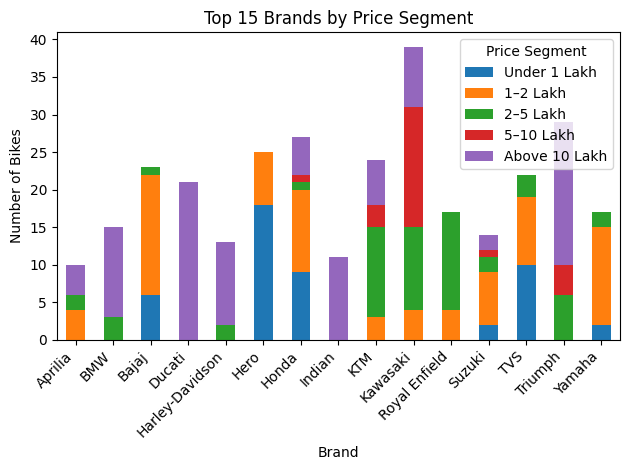

In [130]:
brand_price_segment.plot(
    kind="bar",
    stacked=True,
    #figsize=(12, 7)
)

plt.title("Top 15 Brands by Price Segment")
plt.xlabel("Brand")
plt.ylabel("Number of Bikes")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Price Segment")

plt.tight_layout()
plt.show()

In [131]:
price_rating_data = df_analysis[
    ["ex_showroom_price", "rating"]
].dropna()

correlation = price_rating_data[
    "ex_showroom_price"
].corr(
    price_rating_data["rating"]
)

print("Observations used:", len(price_rating_data))
print("Pearson correlation:", round(correlation, 3))

Observations used: 400
Pearson correlation: 0.07


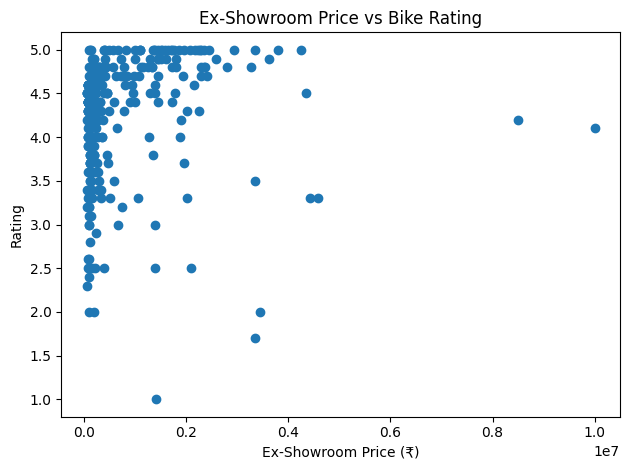

In [133]:
#plt.figure(figsize=(10, 6))

plt.scatter(
    price_rating_data["ex_showroom_price"],
    price_rating_data["rating"]
)

plt.title("Ex-Showroom Price vs Bike Rating")
plt.xlabel("Ex-Showroom Price (₹)")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

In [135]:
import numpy as np

price_rating_log = price_rating_data.copy()

price_rating_log["log_price"] = np.log1p(
    price_rating_log["ex_showroom_price"]
)

log_correlation = price_rating_log[
    "log_price"
].corr(
    price_rating_log["rating"]
)

print(
    "Pearson correlation (Log Price vs Rating):",
    round(log_correlation, 3)
)

Pearson correlation (Log Price vs Rating): 0.187


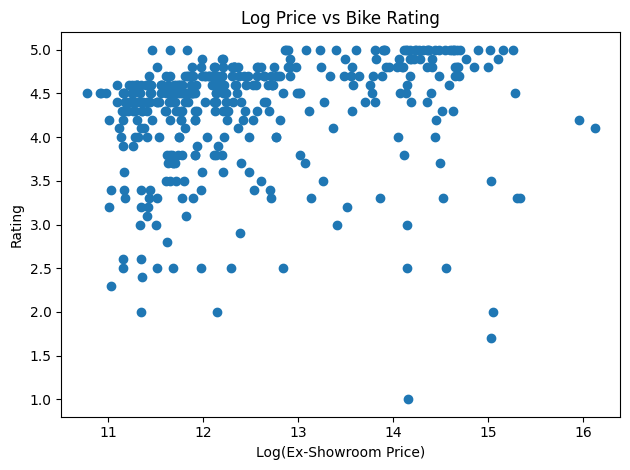

In [136]:
#plt.figure(figsize=(10, 6))

plt.scatter(
    price_rating_log["log_price"],
    price_rating_log["rating"]
)

plt.title("Log Price vs Bike Rating")
plt.xlabel("Log(Ex-Showroom Price)")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

In [137]:
engine_power_df = df[["engine_cc", "power_bhp"]].dropna()

correlation = engine_power_df["engine_cc"].corr(
    engine_power_df["power_bhp"]
)

print("Observations used:", len(engine_power_df))
print("Pearson correlation:", round(correlation, 3))

Observations used: 327
Pearson correlation: 0.834


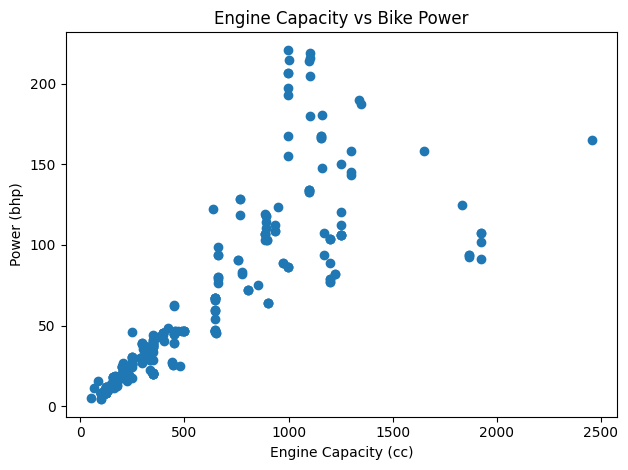

In [138]:
#plt.figure(figsize=(10, 6))

plt.scatter(
    engine_power_df["engine_cc"],
    engine_power_df["power_bhp"]
)

plt.title("Engine Capacity vs Bike Power")
plt.xlabel("Engine Capacity (cc)")
plt.ylabel("Power (bhp)")

plt.tight_layout()
plt.show()

In [139]:
engine_mileage_df = df[["engine_cc", "mileage_kmpl"]].dropna()

correlation = engine_mileage_df["engine_cc"].corr(
    engine_mileage_df["mileage_kmpl"]
)

print("Observations used:", len(engine_mileage_df))
print("Pearson correlation:", round(correlation, 3))

Observations used: 270
Pearson correlation: -0.745


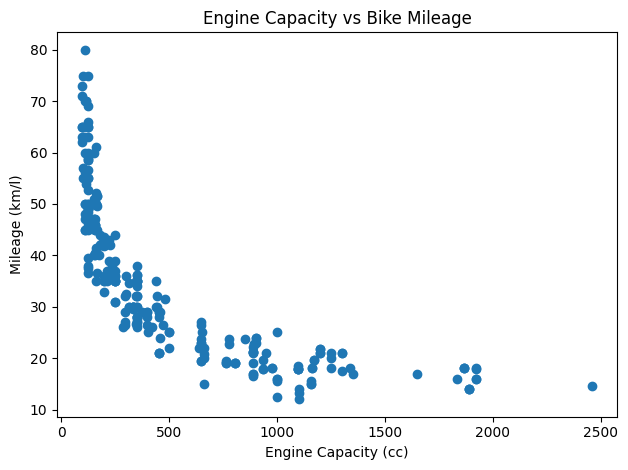

In [140]:
#plt.figure(figsize=(10, 6))

plt.scatter(
    engine_mileage_df["engine_cc"],
    engine_mileage_df["mileage_kmpl"]
)

plt.title("Engine Capacity vs Bike Mileage")
plt.xlabel("Engine Capacity (cc)")
plt.ylabel("Mileage (km/l)")

plt.tight_layout()
plt.show()

In [141]:
brand_summary = (
    df.groupby("brand_clean")
      .agg(
          bike_count=("bike_name", "count"),
          avg_price=("ex_showroom_price", "mean"),
          avg_power=("power_bhp", "mean"),
          avg_mileage=("mileage_kmpl", "mean"),
          avg_rating=("rating", "mean")
      )
      .query("bike_count >= 5")
      .sort_values("bike_count", ascending=False)
)

brand_summary.round(2)

,bike_count,avg_price,avg_power,avg_mileage,avg_rating
brand_clean,,,,,
Kawasaki,39,790271.28,69.45,24.81,4.34
Triumph,29,1175719.76,88.34,22.03,4.31
Honda,27,553079.19,39.70,44.14,4.36
Hero,25,99735.84,12.27,55.08,4.46
KTM,24,691050.71,52.09,28.21,4.54
Bajaj,23,126443.83,18.47,48.02,4.37
TVS,22,120076.95,15.19,49.71,4.39
Ducati,21,2893033.62,135.90,16.66,4.33
Royal Enfield,17,283584.41,34.81,28.84,4.56


In [142]:
rating_engagement_df = df[
    ["rating", "rating_count"]
].dropna()

correlation = rating_engagement_df["rating"].corr(
    rating_engagement_df["rating_count"]
)

print("Observations used:", len(rating_engagement_df))
print("Pearson correlation:", round(correlation, 3))

Observations used: 400
Pearson correlation: 0.102


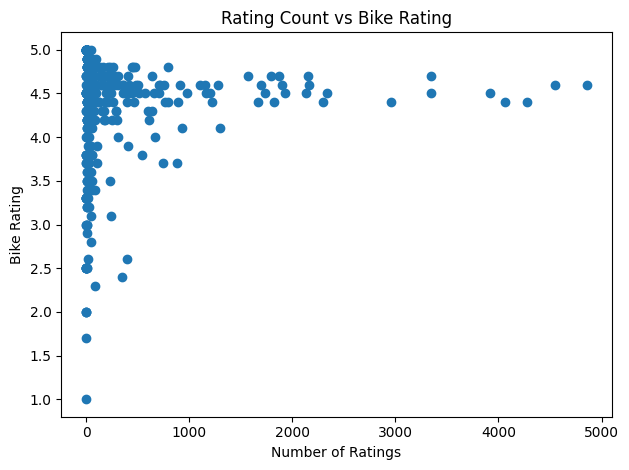

In [143]:
#plt.figure(figsize=(10, 6))

plt.scatter(
    rating_engagement_df["rating_count"],
    rating_engagement_df["rating"]
)

plt.title("Rating Count vs Bike Rating")
plt.xlabel("Number of Ratings")
plt.ylabel("Bike Rating")

plt.tight_layout()
plt.show()

In [144]:
rating_log_df = df[
    ["rating", "rating_count"]
].dropna().copy()

rating_log_df["log_rating_count"] = np.log1p(
    rating_log_df["rating_count"]
)

correlation = rating_log_df["log_rating_count"].corr(
    rating_log_df["rating"]
)

print(
    "Pearson correlation (Log Rating Count vs Rating):",
    round(correlation, 3)
)

Pearson correlation (Log Rating Count vs Rating): 0.182


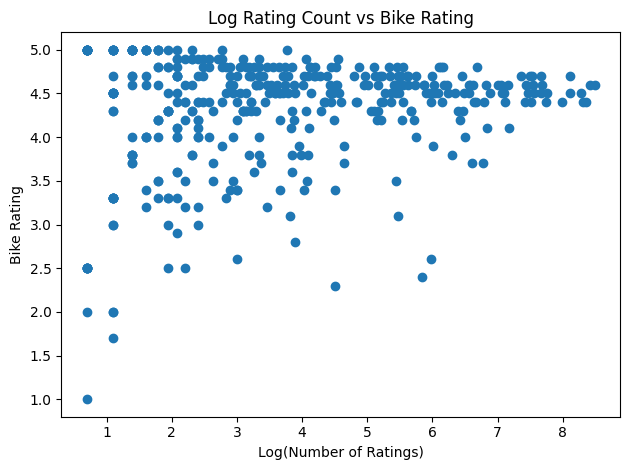

In [145]:
#plt.figure(figsize=(10, 6))

plt.scatter(
    rating_log_df["log_rating_count"],
    rating_log_df["rating"]
)

plt.title("Log Rating Count vs Bike Rating")
plt.xlabel("Log(Number of Ratings)")
plt.ylabel("Bike Rating")

plt.tight_layout()
plt.show()

In [146]:
price_mileage_df = df[
    ["ex_showroom_price", "mileage_kmpl"]
].dropna().copy()

correlation = price_mileage_df[
    "ex_showroom_price"
].corr(
    price_mileage_df["mileage_kmpl"]
)

print("Observations used:", len(price_mileage_df))
print("Pearson correlation:", round(correlation, 3))

Observations used: 270
Pearson correlation: -0.598


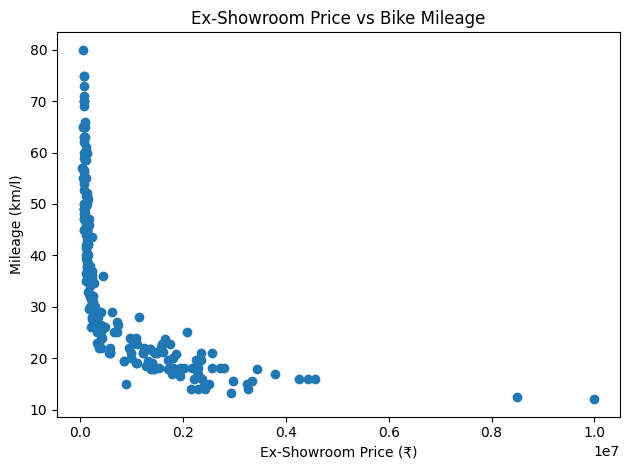

In [147]:
#plt.figure(figsize=(10, 6))

plt.scatter(
    price_mileage_df["ex_showroom_price"],
    price_mileage_df["mileage_kmpl"]
)

plt.title("Ex-Showroom Price vs Bike Mileage")
plt.xlabel("Ex-Showroom Price (₹)")
plt.ylabel("Mileage (km/l)")

plt.tight_layout()
plt.show()

In [148]:
brand_price = (
    df.groupby("brand_clean")["ex_showroom_price"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

print(brand_price)

brand_clean
Ducati                 2.893034e+06
Harley-Davidson        2.306806e+06
BMW                    1.902305e+06
Indian                 1.732763e+06
Moto Guzzi             1.645802e+06
Triumph                1.175720e+06
Aprilia                1.043408e+06
Kawasaki               7.902713e+05
KTM                    6.910507e+05
Brixton Motorcycles    6.789868e+05
Benelli                6.289645e+05
Honda                  5.530792e+05
Moto Morini            5.395840e+05
Suzuki                 3.959429e+05
BSA                    3.322450e+05
Name: ex_showroom_price, dtype: float64


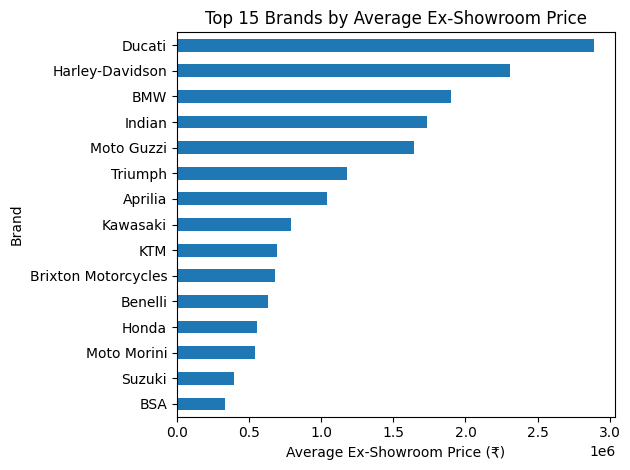

In [150]:
#plt.figure(figsize=(12, 7))

brand_price.sort_values().plot(kind="barh")

plt.title("Top 15 Brands by Average Ex-Showroom Price")
plt.xlabel("Average Ex-Showroom Price (₹)")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

In [151]:
top_power_to_weight = (
    df[["bike_name", "brand_clean", "power_bhp", "weight_kg", "power_to_weight"]]
    .dropna(subset=["power_to_weight"])
    .sort_values("power_to_weight", ascending=False)
    .head(15)
)

print(top_power_to_weight)

                          bike_name brand_clean  power_bhp  weight_kg  \
143  Ducati Panigale V4 Lamborghini      Ducati     216.00      185.0   
168              Ducati Panigale V4      Ducati     219.00      188.0   
217            Ducati Panigale V4 R      Ducati     221.00      193.5   
171     Honda CBR1000RR-R Fireblade       Honda     214.56      201.0   
282       Aprilia RSV4 1100 Factory     Aprilia     213.89      202.0   
101                     BMW S1000RR         BMW     206.51      197.0   
294         Ducati Streetfighter V4      Ducati     205.00      197.5   
214                    BMW M 1000 R         BMW     206.50      210.0   
102           Kawasaki Ninja ZX-10R    Kawasaki     193.00      207.0   
287    Triumph Speed Triple 1200 RS     Triumph     180.50      199.0   
148           KTM 1390 Super Duke R         KTM     187.70      210.0   
272                    BMW S 1000 R         BMW     167.60      199.0   
312        Triumph Street Triple RX     Triumph    

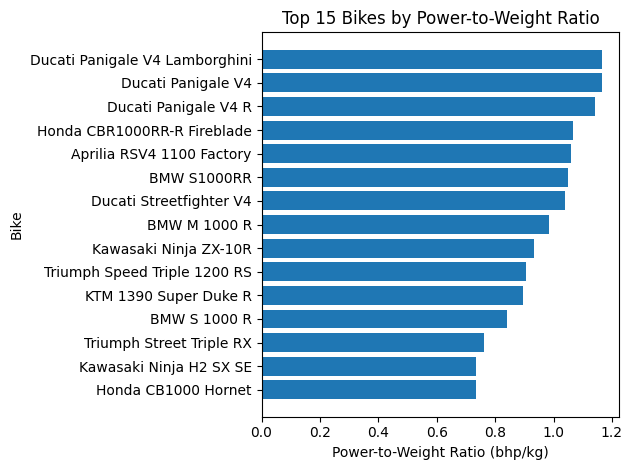

In [152]:
#plt.figure(figsize=(12, 7))

plot_data = top_power_to_weight.sort_values("power_to_weight")

plt.barh(
    plot_data["bike_name"],
    plot_data["power_to_weight"]
)

plt.title("Top 15 Bikes by Power-to-Weight Ratio")
plt.xlabel("Power-to-Weight Ratio (bhp/kg)")
plt.ylabel("Bike")

plt.tight_layout()
plt.show()

In [153]:
top_price_per_bhp = (
    df[["bike_name", "brand_clean", "ex_showroom_price",
        "power_bhp", "price_per_bhp"]]
    .dropna(subset=["price_per_bhp"])
    .sort_values("price_per_bhp", ascending=True)
    .head(15)
)

print(top_price_per_bhp)

                       bike_name    brand_clean  ex_showroom_price  power_bhp  \
21           Bajaj Pulsar NS400Z          Bajaj             186150      40.04   
61             Bajaj Dominar 400          Bajaj             208330      40.04   
52                TVS Apache RTX            TVS             199496      35.50   
30            Bajaj Pulsar NS200          Bajaj             139279      24.13   
78              Hero Xtreme 250R           Hero             172591      29.50   
64             Bajaj Pulsar N250          Bajaj             145487      24.10   
119          Triumph Tracker 400        Triumph             242064      39.45   
276                  Zontes 350X         Zontes             237040      38.20   
19   Royal Enfield Guerrilla 450  Royal Enfield             251063      39.47   
40             Triumph Speed 400        Triumph             234302      36.49   
80            TVS Apache RTR 310            TVS             225283      35.08   
7                      TVS R

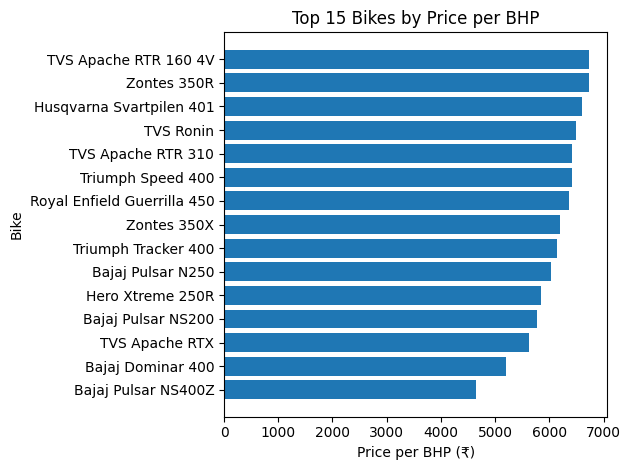

In [154]:
#plt.figure(figsize=(12, 7))

plot_data = top_price_per_bhp.sort_values("price_per_bhp")

plt.barh(
    plot_data["bike_name"],
    plot_data["price_per_bhp"]
)

plt.title("Top 15 Bikes by Price per BHP")
plt.xlabel("Price per BHP (₹)")
plt.ylabel("Bike")

plt.tight_layout()
plt.show()

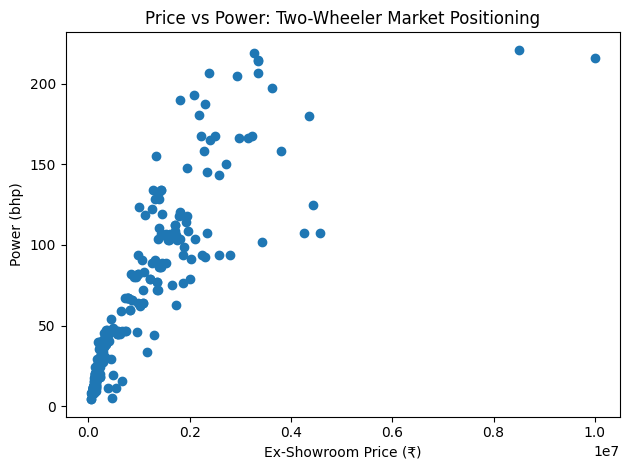

Observations used: 327


In [155]:
price_power = df.dropna(
    subset=["ex_showroom_price", "power_bhp"]
).copy()

#plt.figure(figsize=(12, 7))

plt.scatter(
    price_power["ex_showroom_price"],
    price_power["power_bhp"]
)

plt.title("Price vs Power: Two-Wheeler Market Positioning")
plt.xlabel("Ex-Showroom Price (₹)")
plt.ylabel("Power (bhp)")

plt.tight_layout()
plt.show()

print("Observations used:", len(price_power))

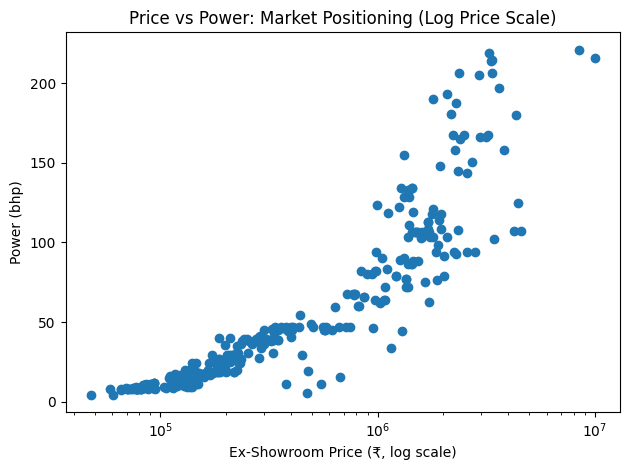

In [156]:
#plt.figure(figsize=(12, 7))

plt.scatter(
    price_power["ex_showroom_price"],
    price_power["power_bhp"]
)

plt.xscale("log")

plt.title("Price vs Power: Market Positioning (Log Price Scale)")
plt.xlabel("Ex-Showroom Price (₹, log scale)")
plt.ylabel("Power (bhp)")

plt.tight_layout()
plt.show()

In [157]:
# Performance Value Analysis
value_bikes = df[
    df["price_per_bhp"].notna()
].copy()

value_bikes = value_bikes.sort_values(
    "price_per_bhp",
    ascending=True
)

value_bikes[
    [
        "bike_name",
        "brand_clean",
        "ex_showroom_price",
        "power_bhp",
        "price_per_bhp"
    ]
].head(20)

,bike_name,brand_clean,ex_showroom_price,power_bhp,price_per_bhp
21,Bajaj Pulsar NS400Z,Bajaj,186150,40.04,4649.100899
61,Bajaj Dominar 400,Bajaj,208330,40.04,5203.046953
52,TVS Apache RTX,TVS,199496,35.50,5619.605634
30,Bajaj Pulsar NS200,Bajaj,139279,24.13,5772.026523
78,Hero Xtreme 250R,Hero,172591,29.50,5850.542373
64,Bajaj Pulsar N250,Bajaj,145487,24.10,6036.804979
119,Triumph Tracker 400,Triumph,242064,39.45,6135.969582
276,Zontes 350X,Zontes,237040,38.20,6205.235602
19,Royal Enfield Guerrilla 450,Royal Enfield,251063,39.47,6360.856347
40,Triumph Speed 400,Triumph,234302,36.49,6420.992053


In [158]:
print("Number of bikes evaluated:", len(value_bikes))

Number of bikes evaluated: 327


In [159]:
brand_value = (
    df.groupby("brand_clean")["price_per_bhp"]
      .agg(["count", "mean", "median"])
      .sort_values("mean")
)

brand_value.head(15)

,count,mean,median
brand_clean,,,
Yezdi,3,7002.063358,7036.236934
Husqvarna,2,7012.311772,7012.311772
Zontes,4,7140.615183,6963.743455
BSA,2,7284.501373,7284.501373
Jawa,5,7341.373040,7149.406981
Bajaj,21,7503.161961,7446.799765
Royal Enfield,16,8339.639923,8141.079800
TVS,19,8470.107562,8132.920792
Hero,25,8520.423302,8271.800948


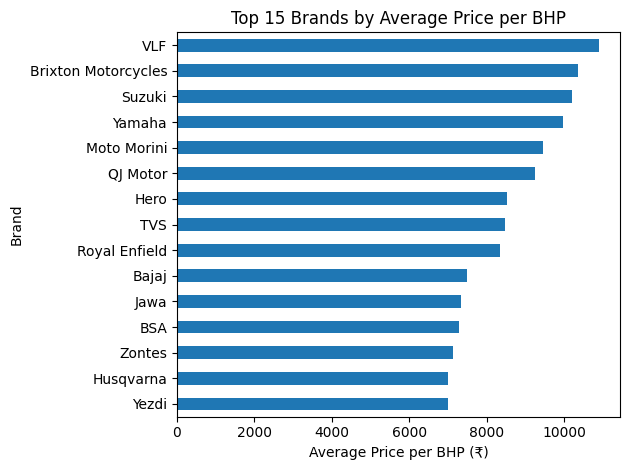

In [161]:
#plt.figure(figsize=(10, 6))

brand_value.head(15)["mean"].sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Brands by Average Price per BHP")
plt.xlabel("Average Price per BHP (₹)")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

## Multivariate EDA — Correlation Analysis

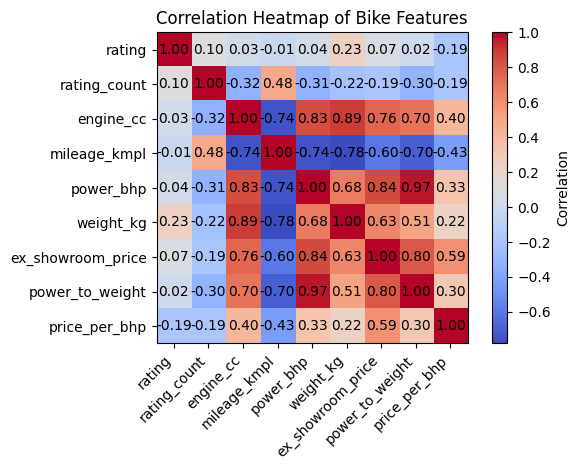

In [163]:
corr_cols = [
    'rating',
    'rating_count',
    'engine_cc',
    'mileage_kmpl',
    'power_bhp',
    'weight_kg',
    'ex_showroom_price',
    'power_to_weight',
    'price_per_bhp'
]

corr_matrix = df[corr_cols].corr()

#plt.figure(figsize=(12, 8))

plt.imshow(
    corr_matrix,
    cmap='coolwarm',
    interpolation='nearest'
)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(corr_cols)),
    corr_cols,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(corr_cols)),
    corr_cols
)

plt.title("Correlation Heatmap of Bike Features")

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.tight_layout()
plt.show()

In [164]:
display(corr_matrix.round(3))

,rating,rating_count,engine_cc,mileage_kmpl,power_bhp,weight_kg,ex_showroom_price,power_to_weight,price_per_bhp
rating,1.000,0.102,0.032,-0.009,0.040,0.231,0.070,0.017,-0.189
rating_count,0.102,1.000,-0.315,0.484,-0.310,-0.217,-0.187,-0.301,-0.188
engine_cc,0.032,-0.315,1.000,-0.745,0.834,0.888,0.756,0.704,0.404
mileage_kmpl,-0.009,0.484,-0.745,1.000,-0.742,-0.781,-0.598,-0.700,-0.432
power_bhp,0.040,-0.310,0.834,-0.742,1.000,0.679,0.844,0.966,0.330
weight_kg,0.231,-0.217,0.888,-0.781,0.679,1.000,0.631,0.511,0.223
ex_showroom_price,0.070,-0.187,0.756,-0.598,0.844,0.631,1.000,0.799,0.592
power_to_weight,0.017,-0.301,0.704,-0.700,0.966,0.511,0.799,1.000,0.301
price_per_bhp,-0.189,-0.188,0.404,-0.432,0.330,0.223,0.592,0.301,1.000


In [165]:
segment_analysis = (
    df.groupby("price_segment", observed=True)
      .agg(
          bike_count=("bike_name", "count"),
          avg_engine_cc=("engine_cc", "mean"),
          avg_power_bhp=("power_bhp", "mean"),
          avg_mileage_kmpl=("mileage_kmpl", "mean"),
          avg_weight_kg=("weight_kg", "mean"),
          avg_rating=("rating", "mean")
    )
)

display(segment_analysis.round(2))

,bike_count,avg_engine_cc,avg_power_bhp,avg_mileage_kmpl,avg_weight_kg,avg_rating
price_segment,,,,,,
Under 1 Lakh,86,114.68,8.75,58.23,104.01,4.07
1–2 Lakh,142,196.90,17.22,42.09,138.87,4.27
2–5 Lakh,83,369.73,35.65,29.63,175.59,4.39
5–10 Lakh,33,593.84,60.20,22.48,186.30,4.45
Above 10 Lakh,100,1113.16,121.30,18.60,232.77,4.47


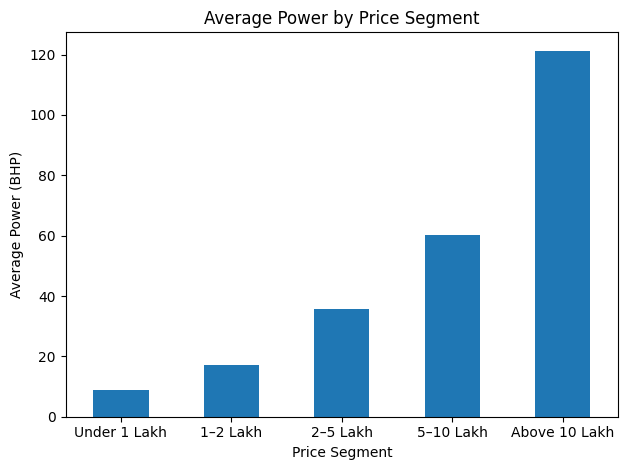

In [166]:
segment_analysis["avg_power_bhp"].plot(
    kind="bar",
    #figsize=(10, 6)
)

plt.title("Average Power by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Average Power (BHP)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

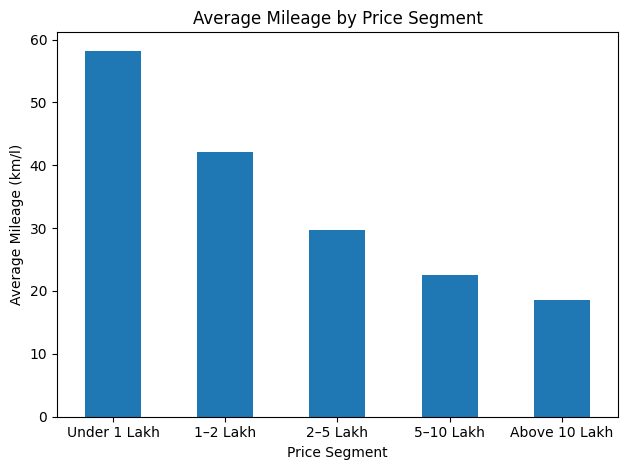

In [167]:
segment_analysis["avg_mileage_kmpl"].plot(
    kind="bar",
    #figsize=(10, 6)
)

plt.title("Average Mileage by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Average Mileage (km/l)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

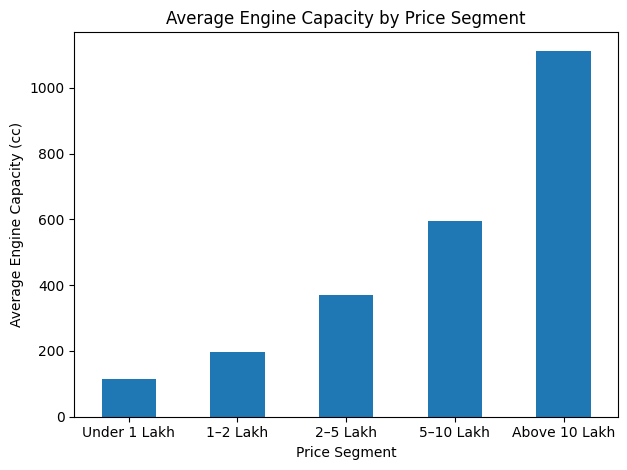

In [169]:
segment_analysis["avg_engine_cc"].plot(
    kind="bar",
    #figsize=(10, 6)
)

plt.title("Average Engine Capacity by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Average Engine Capacity (cc)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [172]:
brand_value_analysis = (
    df_clean.dropna(subset=["price_per_bhp"])
    .groupby("brand")
    .agg(
        bike_count=("bike_name", "count"),
        avg_price_per_bhp=("price_per_bhp", "mean"),
        median_price_per_bhp=("price_per_bhp", "median")
    )
)

# Keep brands with at least 3 bikes
brand_value_analysis = (
    brand_value_analysis[
        brand_value_analysis["bike_count"] >= 3
    ]
    .sort_values("avg_price_per_bhp")
)

brand_value_analysis

,bike_count,avg_price_per_bhp,median_price_per_bhp
brand,,,
Yezdi,3,7002.063358,7036.236934
Zontes,4,7140.615183,6963.743455
Jawa,5,7341.373040,7149.406981
Bajaj,21,7503.161961,7446.799765
Royal Enfield,16,8339.639923,8141.079800
TVS,19,8470.107562,8132.920792
Hero,25,8520.423302,8271.800948
QJ Motor,4,9233.957622,9120.469331
Yamaha,15,9975.041196,9916.203390


In [173]:
top_15_brand_value = brand_value_analysis.head(15)

top_15_brand_value

,bike_count,avg_price_per_bhp,median_price_per_bhp
brand,,,
Yezdi,3,7002.063358,7036.236934
Zontes,4,7140.615183,6963.743455
Jawa,5,7341.373040,7149.406981
Bajaj,21,7503.161961,7446.799765
Royal Enfield,16,8339.639923,8141.079800
TVS,19,8470.107562,8132.920792
Hero,25,8520.423302,8271.800948
QJ Motor,4,9233.957622,9120.469331
Yamaha,15,9975.041196,9916.203390


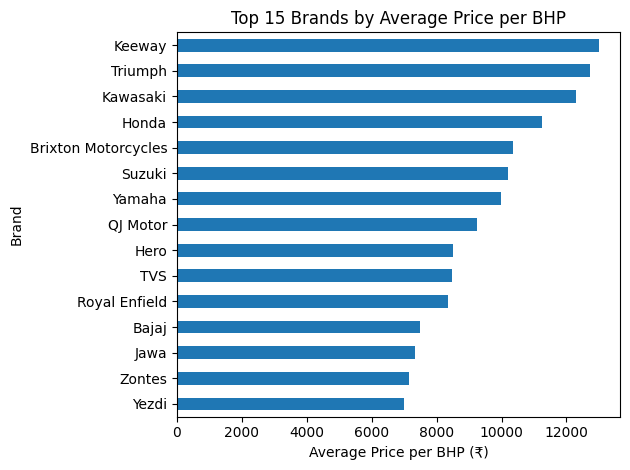

In [175]:
#plt.figure(figsize=(10, 7))

top_15_brand_value["avg_price_per_bhp"].sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Brands by Average Price per BHP")
plt.xlabel("Average Price per BHP (₹)")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

In [176]:
business_insights = pd.DataFrame({
    "Analysis": [
        "Price vs Power",
        "Engine Capacity vs Power",
        "Engine Capacity vs Mileage",
        "Price vs Mileage",
        "Price vs Engine Capacity",
        "Price vs Rating",
        "Rating Count vs Rating",
        "Price Segment Distribution",
        "Average Power by Price Segment",
        "Average Mileage by Price Segment",
        "Average Engine Capacity by Price Segment"
    ],
    
    "Finding": [
        "Strong positive correlation (r = 0.844)",
        "Strong positive correlation (r = 0.834)",
        "Strong negative correlation (r = -0.745)",
        "Moderate negative correlation (r = -0.598)",
        "Strong positive correlation (r = 0.756)",
        "Very weak positive correlation (r = 0.070)",
        "Very weak positive correlation (r = 0.102)",
        "1–2 Lakh segment contains the largest number of bikes (142)",
        "Average power rises from 8.75 BHP to 121.30 BHP",
        "Average mileage decreases from 58.23 to 18.60 km/l",
        "Average engine capacity rises from 114.68 cc to 1,113.16 cc"
    ],
    
    "Business_Interpretation": [
        "Higher-priced bikes generally tend to offer higher power.",
        "Larger-engine bikes generally produce higher power.",
        "Higher engine capacity is generally associated with lower mileage.",
        "Higher-priced bikes in this dataset generally show lower mileage.",
        "Higher-priced bikes generally have larger engine capacities.",
        "Bike price shows little linear relationship with user rating.",
        "Number of ratings shows little linear relationship with bike rating.",
        "The ₹1–2 Lakh segment represents the largest observed price segment.",
        "Higher price segments are associated with substantially higher power.",
        "Lower-priced segments are more strongly associated with fuel efficiency.",
        "Higher-priced segments are strongly associated with larger engines."
    ]
})

business_insights

,Analysis,Finding,Business_Interpretation
0,Price vs Power,Strong positive correlation (r = 0.844),Higher-priced bikes generally tend to offer hi...
1,Engine Capacity vs Power,Strong positive correlation (r = 0.834),Larger-engine bikes generally produce higher p...
2,Engine Capacity vs Mileage,Strong negative correlation (r = -0.745),Higher engine capacity is generally associated...
3,Price vs Mileage,Moderate negative correlation (r = -0.598),Higher-priced bikes in this dataset generally ...
4,Price vs Engine Capacity,Strong positive correlation (r = 0.756),Higher-priced bikes generally have larger engi...
5,Price vs Rating,Very weak positive correlation (r = 0.070),Bike price shows little linear relationship wi...
6,Rating Count vs Rating,Very weak positive correlation (r = 0.102),Number of ratings shows little linear relation...
7,Price Segment Distribution,1–2 Lakh segment contains the largest number o...,The ₹1–2 Lakh segment represents the largest o...
8,Average Power by Price Segment,Average power rises from 8.75 BHP to 121.30 BHP,Higher price segments are associated with subs...
9,Average Mileage by Price Segment,Average mileage decreases from 58.23 to 18.60 ...,Lower-priced segments are more strongly associ...


In [177]:
print("Final dataset shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:", df_clean.duplicated().sum())

print("Duplicate bike URLs:", df_clean["bike_url"].duplicated().sum())

Final dataset shape: (444, 13)

Missing values:
bike_name              0
brand                  0
bike_url               0
rating                44
rating_count          44
engine_cc            109
mileage_kmpl         174
power_bhp            117
weight_kg             27
ex_showroom_price      0
price_segment          0
power_to_weight      125
price_per_bhp        117
dtype: int64

Duplicate rows: 0
Duplicate bike URLs: 0


## Conclusion

This project analyzed 444 bike listings collected through web scraping and transformed the raw website data into a structured dataset for exploratory and business-oriented analysis. The analysis identified strong relationships among price, engine capacity and power, with higher-priced bikes generally associated with larger engines and greater power. At the same time, engine capacity and price showed negative relationships with mileage, indicating an observable performance–efficiency trade-off within the scraped dataset.

The ₹1–2 lakh segment represented the largest share of the collected listings, while higher price segments showed substantially greater average engine capacity and power. Brand-level analysis also showed considerable variation in average price per BHP, highlighting differences in the relationship between listed price and power across manufacturers.

Bike ratings showed very weak linear relationships with both price and rating count, suggesting that these variables alone do not explain the displayed ratings. Overall, the project demonstrates an end-to-end workflow covering web scraping, data cleaning, feature engineering, exploratory data analysis, correlation analysis, segmentation and business interpretation.

## Limitations

- The analysis is based on 444 bike listings collected from the publicly accessible BikeWale listing pages and therefore represents the scraped dataset rather than the entire Indian two-wheeler market.
- Some technical specifications were unavailable for certain listings, resulting in missing values for variables such as engine capacity, mileage, power and derived performance metrics.
- The available specifications were not completely consistent across all bike types, particularly for electric vehicles, which may limit direct comparison with conventional petrol motorcycles.
- Correlation analysis identifies linear associations between variables but does not establish causal relationships.
- Price values represent the available ex-showroom prices in the scraped listings and may vary based on location, variant, taxes, offers and other market conditions.
- Ratings and rating counts reflect the information available on the website at the time of data collection and may change over time.

## Business Insights & Recommendations

1. Price–Performance Relationship
The analysis shows a strong positive relationship between ex-showroom price and power (Pearson correlation = 0.844). Higher-priced bikes in the dataset generally offer higher engine performance and power.

- Business implication: Customers looking for higher performance should expect higher prices, while manufacturers can position models across different price-performance segments.

2. Engine Capacity and Power
Engine capacity and power have a strong positive correlation (0.834), indicating that bikes with larger engine capacities generally produce higher power.

- Business implication: Engine capacity can be considered an important specification when comparing performance-oriented motorcycles.

3. Performance–Efficiency Trade-off
Engine capacity and mileage have a strong negative correlation (-0.745). Price and mileage also show a negative correlation (-0.598).

- Business implication: Buyers may need to balance performance requirements with fuel efficiency when selecting a motorcycle.

4. Dominant Price Segment
The ₹1–2 lakh segment contains the largest number of listings, with 142 bikes (31.98%) of the dataset.

- Business implication: This price range represents a substantial portion of the collected listings and can be considered an important segment for market analysis.

5. Increasing Performance Across Price Segments
Average power increases from 8.75 BHP in the Under ₹1 lakh segment to 121.30 BHP in the Above ₹10 lakh segment.

- Business implication: The collected data shows clear differentiation between price segments based on performance characteristics.

6. Mileage Differences Across Price Segments
Average mileage decreases from 58.23 km/l in the Under ₹1 lakh segment to 18.60 km/l in the Above ₹10 lakh segment.

- Business implication: Lower-priced motorcycles in the dataset generally emphasize fuel efficiency, while higher-priced segments are associated with greater performance specifications.

7. Brand-Level Price per BHP Variation
The analysis of price per BHP shows considerable variation among manufacturers. This metric provides an additional way to compare the relationship between listed price and power output.

- Business implication: Price-per-BHP analysis can help consumers compare performance relative to listed cost rather than considering price alone.

8. Ratings Are Not Strongly Explained by Price or Rating Count
Price vs rating has a very weak correlation (0.070), while rating count vs rating has a very weak correlation (0.102).

- Business implication: The displayed rating in this dataset cannot be meaningfully explained by price or rating count alone. Other factors may influence customer ratings.

## Project Summary

This project developed an end-to-end web scraping and data analytics workflow for analyzing Indian two-wheeler listings from BikeWale. A total of 444 unique bike listings were collected and transformed into a structured dataset containing bike details, brand, ratings, engine capacity, mileage, power, weight and ex-showroom price.

The project covered data collection using Python web scraping techniques, data cleaning and preprocessing using Pandas and Regular Expressions, feature engineering, exploratory data analysis, correlation analysis, price segmentation, brand-level analysis and performance-based metrics such as power-to-weight ratio and price per BHP.

The analysis identified strong relationships between price, engine capacity and power, along with a negative relationship between engine capacity and mileage. The ₹1–2 lakh segment contained the largest share of listings, while higher-priced segments generally showed higher average engine capacity and power. Brand-level analysis also highlighted differences in pricing and price-per-BHP across manufacturers.

Overall, the project demonstrates the practical application of Python, Web Scraping, Pandas, NumPy, Regular Expressions, Matplotlib and exploratory data analysis to convert publicly available web data into structured, business-oriented insights.

In [178]:
# Export final cleaned dataset

output_file = "bikewale_final_cleaned_data.csv"

df_clean.to_csv(output_file, index=False)

print(f"Dataset exported successfully: {output_file}")
print("Final shape:", df_clean.shape)

Dataset exported successfully: bikewale_final_cleaned_data.csv
Final shape: (444, 13)


In [179]:
import os

print("File exists:", os.path.exists("bikewale_final_cleaned_data.csv"))

File exists: True


In [180]:
pd.read_csv("bikewale_final_cleaned_data.csv").head()

,bike_name,brand,bike_url,rating,rating_count,engine_cc,mileage_kmpl,power_bhp,weight_kg,ex_showroom_price,price_segment,power_to_weight,price_per_bhp
0,Honda SP 125,Honda,/honda-bikes/sp-125/,4.6,4548.0,123.94,63.0,10.72,117.0,90636,Under 1 Lakh,0.091624,8454.850746
1,Yamaha MT 15 V2,Yamaha,/yamaha-bikes/mt-15/,4.7,1866.0,155.00,47.0,18.10,141.0,166582,1–2 Lakh,0.128369,9203.425414
2,Royal Enfield Hunter 350,Royal Enfield,/royalenfield-bikes/hunter-350/,4.7,1792.0,349.34,36.2,20.20,181.0,137640,1–2 Lakh,0.111602,6813.861386
3,Royal Enfield Classic 350,Royal Enfield,/royalenfield-bikes/classic-350/,4.6,47.0,349.00,34.0,20.20,195.0,187434,1–2 Lakh,0.103590,9278.910891
4,Bajaj Pulsar N160 2V,Bajaj,/bajaj-bikes/pulsar-n160/,4.6,1278.0,164.82,51.6,15.68,152.0,122990,1–2 Lakh,0.103158,7843.750000


In [181]:
pwd

'C:\\Users\\yaswa\\web scraping'